<a href="https://colab.research.google.com/github/raisaaajose/Raisa-EDA-Project/blob/main/Raisa_EDA_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
# NAME : RAISA JOSE
# REG NO : 23BDS0075
# COURSE : EXPLORATORY DATA ANALYSIS
# COURSE CODE : BCSE331L
# DATE : 25 - 9 - 26

# COURSE PROJECT


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# 1. Loading the dataset
df = pd.read_csv("https://raw.githubusercontent.com/salemprakash/EDA/main/Data/Auto.csv")

# 2. Handling Missing Data & Data Cleaning
print("Initial Missing values count per column:")
print(df.isnull().sum())

# Convert "?" to NaN, then convert column to numeric
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

# Fill missing horsepower with the median value
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].median())

# Convert Origin and Cylinders to categorical
origin_map = {1: 'USA', 2: 'Europe', 3: 'Japan'}
df['origin'] = df['origin'].map(origin_map)
df['cylinders'] = df['cylinders'].astype('category')

# 3. Data Transformation
# Create a new column: Weight per Horsepower
df['weight_per_hp'] = df['weight'] / df['horsepower']

# Create a final clean dataframe
df_clean = df.dropna(subset=['mpg'])

# 4. Basic Statistical Analysis
print("\n Basic Statistical Summary ")
print(df_clean.describe(include='all'))



Initial Missing values count per column:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
year            0
origin          0
name            0
dtype: int64

 Basic Statistical Summary 
               mpg  cylinders  displacement  horsepower       weight  \
count   392.000000      392.0    392.000000  392.000000   392.000000   
unique         NaN        5.0           NaN         NaN          NaN   
top            NaN        4.0           NaN         NaN          NaN   
freq           NaN      199.0           NaN         NaN          NaN   
mean     23.445918        NaN    194.411990  104.469388  2977.584184   
std       7.805007        NaN    104.644004   38.491160   849.402560   
min       9.000000        NaN     68.000000   46.000000  1613.000000   
25%      17.000000        NaN    105.000000   75.000000  2225.250000   
50%      22.750000        NaN    151.000000   93.500000  2803.500000   
75%      29.000000        NaN    27

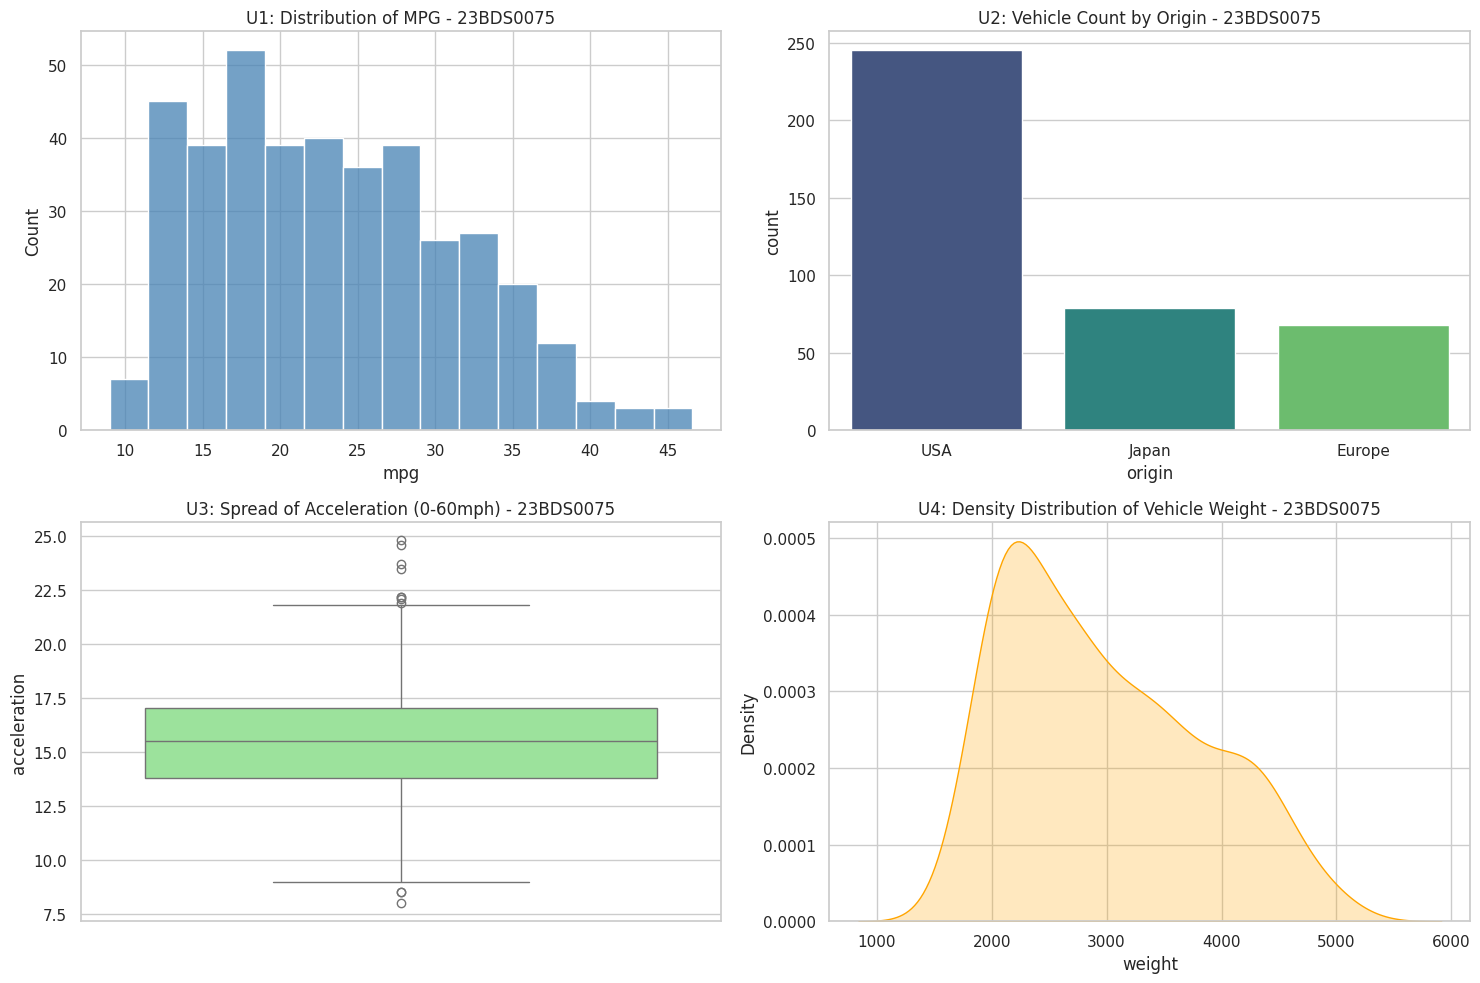

In [15]:
# 5. Univariate Analysis (4 Visualizations)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Viz 1: Distribution of MPG
sns.histplot(df_clean['mpg'], bins=15, color="steelblue", kde=False, ax=axes[0,0])
axes[0,0].set_title("U1: Distribution of MPG - 23BDS0075")

# Viz 2: Count of Cars by Origin
sns.countplot(data=df_clean, x='origin', palette="viridis", ax=axes[0,1])
axes[0,1].set_title("U2: Vehicle Count by Origin - 23BDS0075")

# Viz 3: Spread of Acceleration
sns.boxplot(y=df_clean['acceleration'], color="lightgreen", ax=axes[1,0])
axes[1,0].set_title("U3: Spread of Acceleration (0-60mph) - 23BDS0075")

# Viz 4: Density of Vehicle Weight
sns.kdeplot(df_clean['weight'], fill=True, color="orange", ax=axes[1,1])
axes[1,1].set_title("U4: Density Distribution of Vehicle Weight - 23BDS0075")

plt.tight_layout()
plt.show()

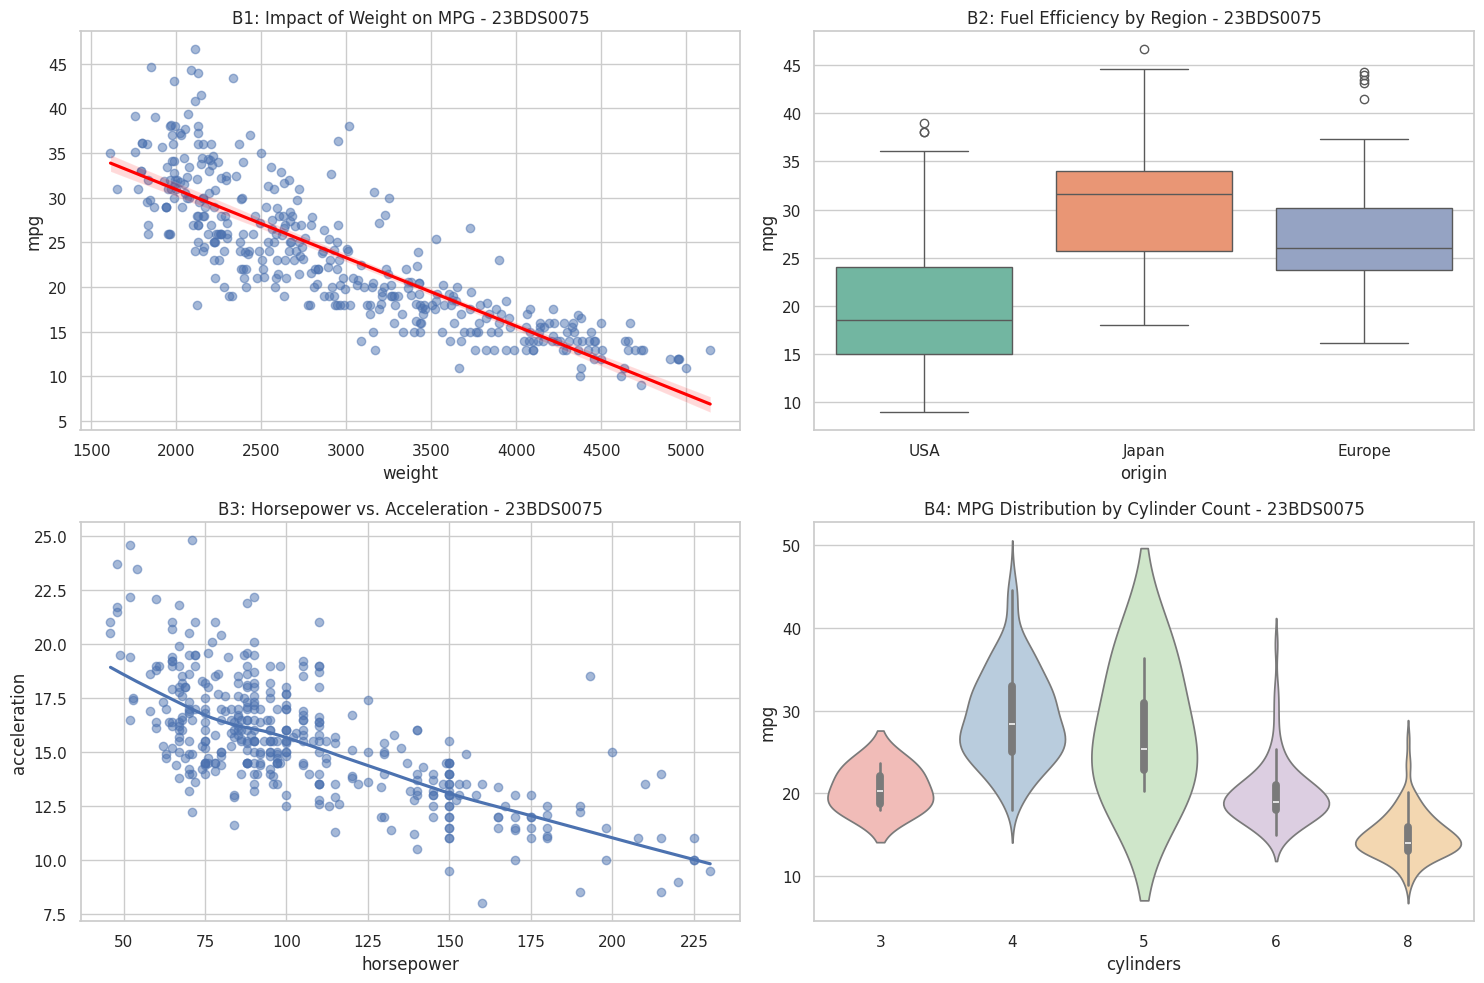

In [16]:
# 6. Bivariate Analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Viz 1: MPG vs Weight (Scatter Plot + Regression Line)
sns.regplot(data=df_clean, x='weight', y='mpg', scatter_kws={'alpha':0.5}, line_kws={'color':'red'}, ax=axes[0,0])
axes[0,0].set_title("B1: Impact of Weight on MPG - 23BDS0075")

# Viz 2: MPG by Origin (Boxplot)
sns.boxplot(data=df_clean, x='origin', y='mpg', palette="Set2", ax=axes[0,1])
axes[0,1].set_title("B2: Fuel Efficiency by Region - 23BDS0075")

# Viz 3: Horsepower vs Acceleration (Scatter Plot + Trend)
sns.regplot(data=df_clean, x='horsepower', y='acceleration', lowess=True, scatter_kws={'alpha':0.5}, ax=axes[1,0])
axes[1,0].set_title("B3: Horsepower vs. Acceleration - 23BDS0075")

# Viz 4: MPG by Cylinder Count (Violin Plot)
sns.violinplot(data=df_clean, x='cylinders', y='mpg', palette="Pastel1", ax=axes[1,1])
axes[1,1].set_title("B4: MPG Distribution by Cylinder Count - 23BDS0075")

plt.tight_layout()
plt.show()

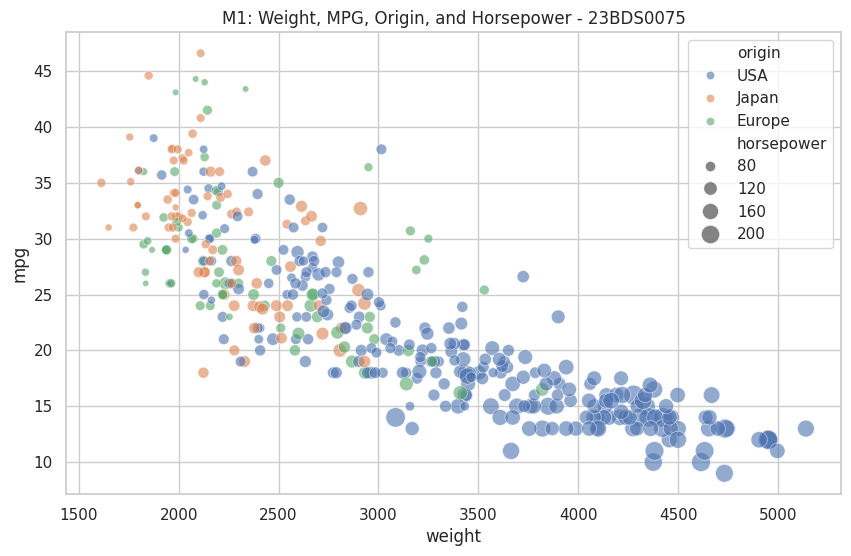

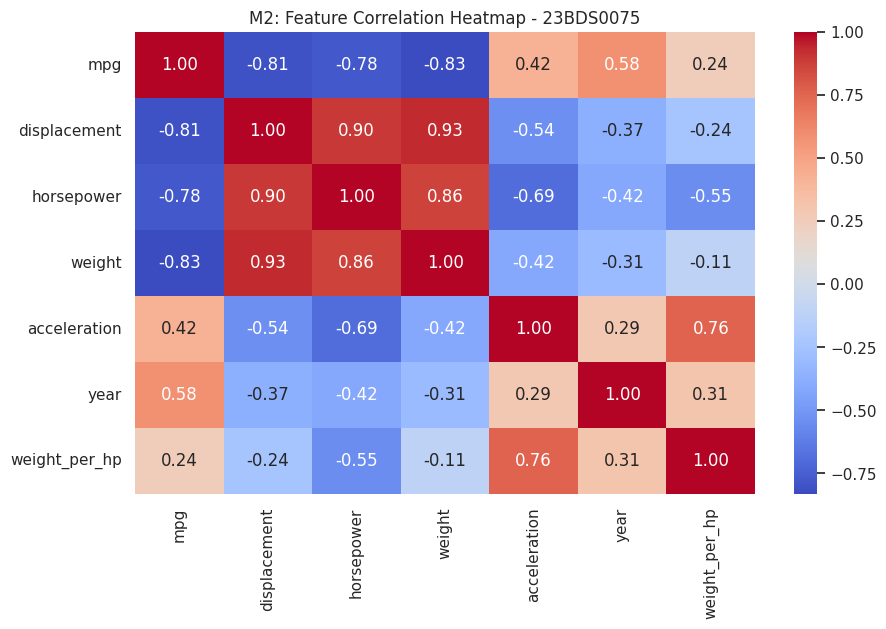

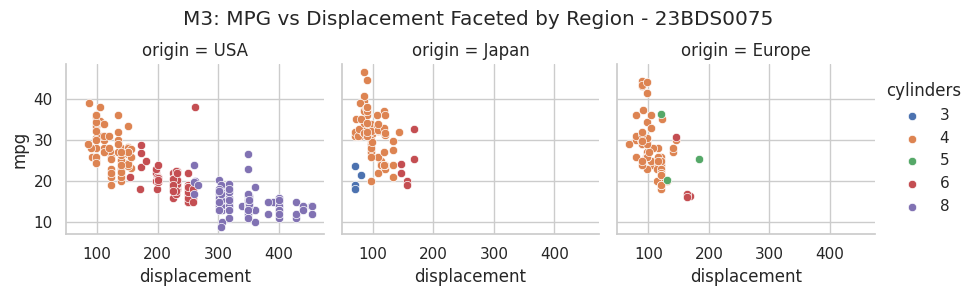

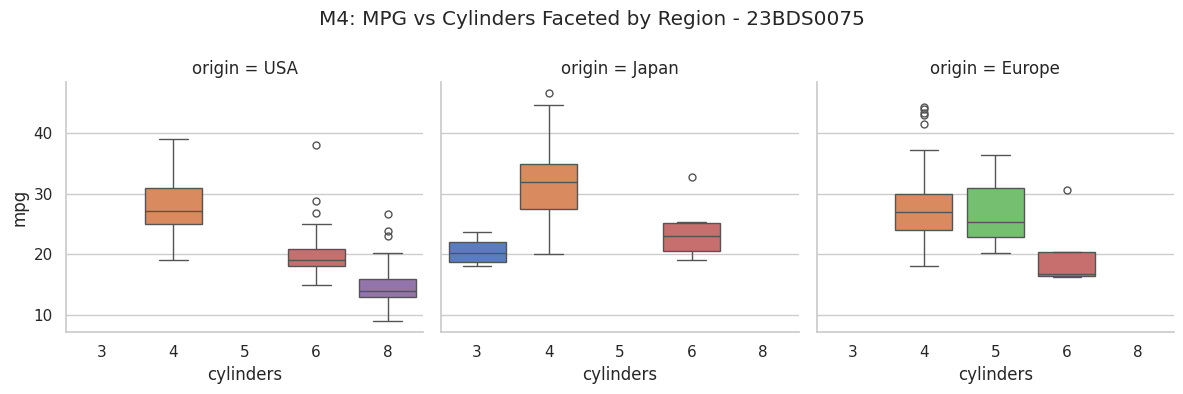

In [17]:
# 7. Multivariate Analysis

# Viz 1: Weight vs MPG colored by Origin and sized by HP
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='weight', y='mpg', hue='origin', size='horsepower', alpha=0.6, sizes=(20, 200))
plt.title("M1: Weight, MPG, Origin, and Horsepower - 23BDS0075")
plt.show()

# Viz 2: Correlation Heatmap
plt.figure(figsize=(10, 6))
numeric_cols = df_clean.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("M2: Feature Correlation Heatmap - 23BDS0075")
plt.show()

# Viz 3: Faceted Scatter Plot (MPG vs Displacement faceted by Origin)
g = sns.FacetGrid(df_clean, col="origin", hue="cylinders")
g.map(sns.scatterplot, "displacement", "mpg")
g.add_legend()
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("M3: MPG vs Displacement Faceted by Region - 23BDS0075")
plt.show()

# Viz 4: Faceted Boxplot (MPG vs Cylinders faceted by Origin)
sns.catplot(data=df_clean, x="cylinders", y="mpg", col="origin", kind="box", palette="muted", height=4, aspect=1)
plt.subplots_adjust(top=0.8)
plt.gcf().suptitle("M4: MPG vs Cylinders Faceted by Region - 23BDS0075")
plt.show()


PHASE 2 - STATISTICAL ANALYSIS AND CLUSTERING

9. 1D / UNIVARIATE STATISTICAL ANALYSIS

Numerical Variables:
['mpg', 'displacement', 'horsepower', 'weight', 'acceleration', 'year', 'weight_per_hp']

Detailed 1D Descriptive Statistics:


,Variable,Count,Mean,Median,Mode,Minimum,Q1,Q3,Maximum,Range,Variance,Standard_Deviation,IQR,Skewness,Kurtosis
0,mpg,392,23.446,22.750,13.0,9.000,17.000,29.000,46.600,37.60,60.918,7.805,12.000,0.457,-0.516
1,displacement,392,194.412,151.000,97.0,68.000,105.000,275.750,455.000,387.00,10950.368,104.644,170.750,0.702,-0.778
2,horsepower,392,104.469,93.500,150.0,46.000,75.000,126.000,230.000,184.00,1481.569,38.491,51.000,1.087,0.697
3,weight,392,2977.584,2803.500,1985.0,1613.000,2225.250,3614.750,5140.000,3527.00,721484.709,849.403,1389.500,0.520,-0.809
4,acceleration,392,15.541,15.500,14.5,8.000,13.775,17.025,24.800,16.80,7.611,2.759,3.250,0.292,0.444
5,year,392,75.980,76.000,73.0,70.000,73.000,79.000,82.000,12.00,13.570,3.684,6.000,0.020,-1.167
6,weight_per_hp,392,29.530,29.167,25.0,13.716,26.259,32.447,48.646,34.93,25.583,5.058,6.188,0.802,1.659



Coefficient of Variation (%):


,Variable,CV_Percentage
0,mpg,33.289
1,displacement,53.826
2,horsepower,36.844
3,weight,28.527
4,acceleration,17.752
5,year,4.848
6,weight_per_hp,17.128



Quantile Table:


,Minimum,10%,25%,50%,75%,90%,Maximum
mpg,9.000,14.000,17.000,22.750,29.000,34.190,46.600
displacement,68.000,90.000,105.000,151.000,275.750,350.000,455.000
horsepower,46.000,67.000,75.000,93.500,126.000,157.700,230.000
weight,1613.000,1990.000,2225.250,2803.500,3614.750,4277.600,5140.000
acceleration,8.000,12.000,13.775,15.500,17.025,19.000,24.800
year,70.000,71.000,73.000,76.000,79.000,81.000,82.000
weight_per_hp,13.716,23.644,26.259,29.167,32.447,35.623,48.646



Origin Frequency Distribution:


,Frequency,Relative_Frequency,Percentage
origin,,,
Europe,68,0.173,17.347
Japan,79,0.202,20.153
USA,245,0.625,62.500



Cylinder Frequency Distribution:


,Frequency,Relative_Frequency,Percentage
cylinders,,,
3,4,0.010,1.020
4,199,0.508,50.765
5,3,0.008,0.765
6,83,0.212,21.173
8,103,0.263,26.276


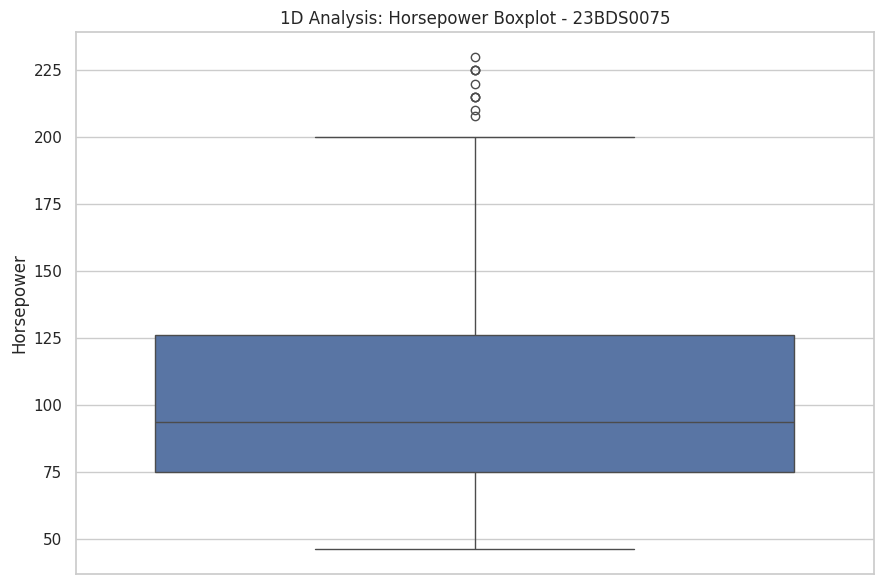

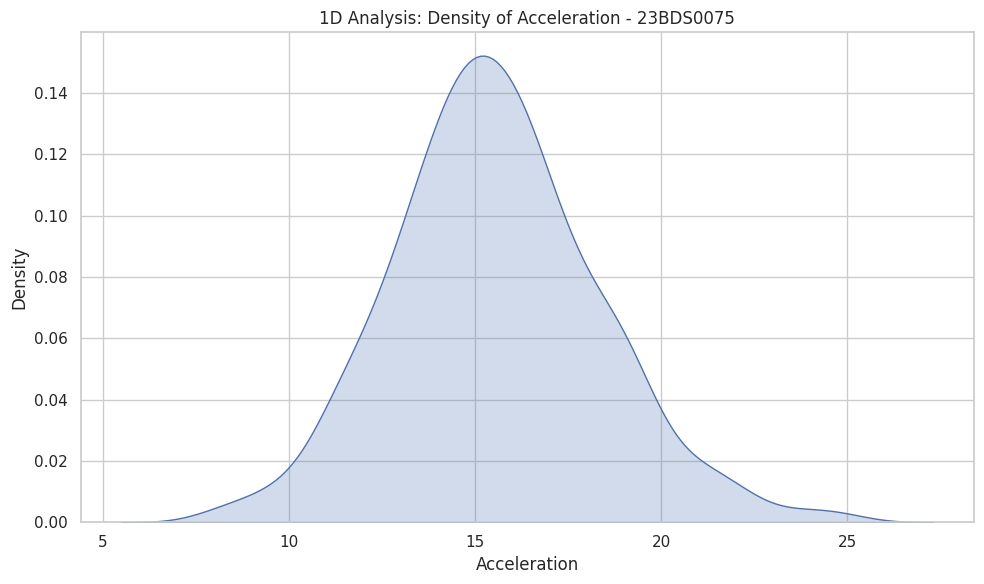


IQR Outlier Summary:


,Variable,Number_of_IQR_Outliers
0,mpg,0
1,displacement,0
2,horsepower,10
3,weight,0
4,acceleration,11
5,year,0
6,weight_per_hp,12


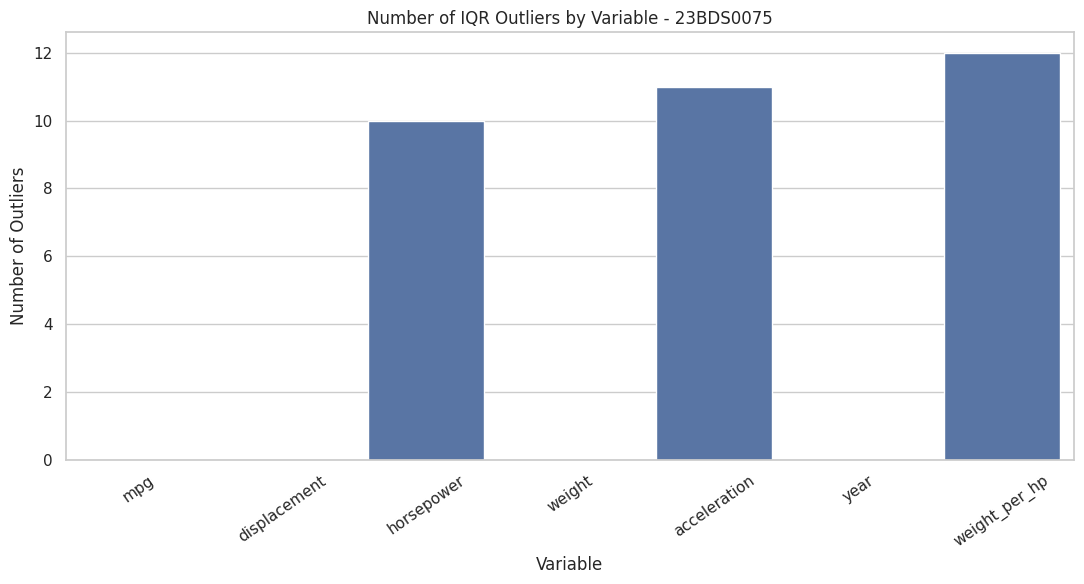


10. 2D / BIVARIATE STATISTICAL ANALYSIS

Covariance Matrix:


,mpg,displacement,horsepower,weight,acceleration,year,weight_per_hp
mpg,60.92,-657.59,-233.86,-5517.44,9.12,16.69,9.53
displacement,-657.59,10950.37,3614.03,82929.10,-156.99,-142.57,-128.23
horsepower,-233.86,3614.03,1481.57,28265.62,-73.19,-59.04,-107.63
weight,-5517.44,82929.10,28265.62,721484.71,-976.82,-967.23,-479.44
acceleration,9.12,-156.99,-73.19,-976.82,7.61,2.95,10.57
year,16.69,-142.57,-59.04,-967.23,2.95,13.57,5.74
weight_per_hp,9.53,-128.23,-107.63,-479.44,10.57,5.74,25.58



Spearman Correlation Matrix:


,mpg,displacement,horsepower,weight,acceleration,year,weight_per_hp
mpg,1.000,-0.855,-0.854,-0.876,0.442,0.575,0.234
displacement,-0.855,1.000,0.876,0.946,-0.499,-0.307,-0.181
horsepower,-0.854,0.876,1.000,0.879,-0.658,-0.389,-0.509
weight,-0.876,0.946,0.879,1.000,-0.405,-0.281,-0.091
acceleration,0.442,-0.499,-0.658,-0.405,1.000,0.278,0.712
year,0.575,-0.307,-0.389,-0.281,0.278,1.000,0.325
weight_per_hp,0.234,-0.181,-0.509,-0.091,0.712,0.325,1.000


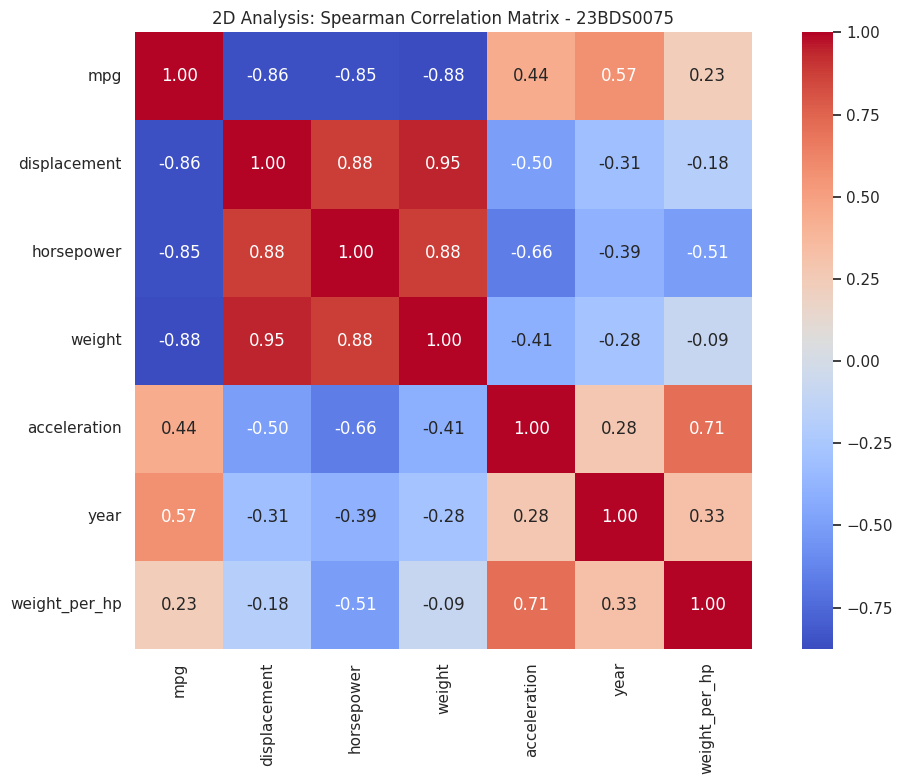


Pearson Correlation Test: MPG vs Weight
Correlation Coefficient: -0.8322
P-value: 6.01529605143857e-102

Spearman Correlation Test: MPG vs Horsepower
Correlation Coefficient: -0.8536
P-value: 1.619383245501938e-112


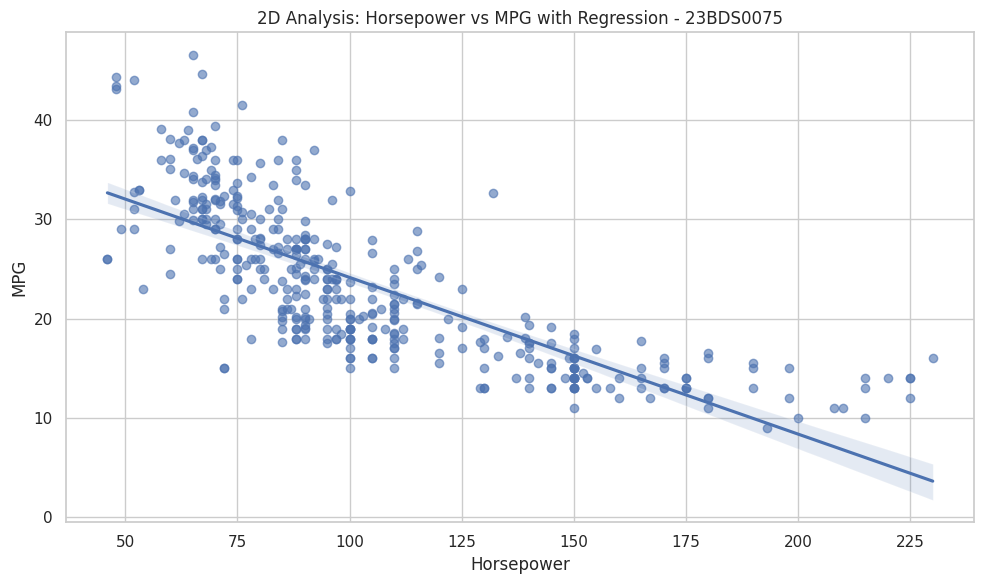


Simple Linear Regression: MPG ~ Weight
                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.693
Model:                            OLS   Adj. R-squared:                  0.692
Method:                 Least Squares   F-statistic:                     878.8
Date:                Fri, 25 Sep 2026   Prob (F-statistic):          6.02e-102
Time:                        14:57:17   Log-Likelihood:                -1130.0
No. Observations:                 392   AIC:                             2264.
Df Residuals:                     390   BIC:                             2272.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   

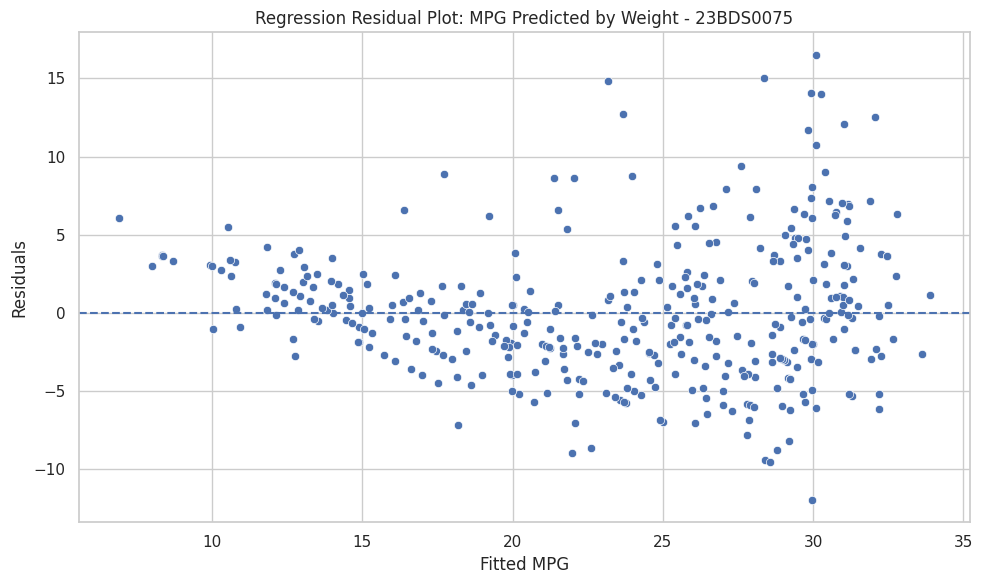


MPG Statistics by Origin:


,origin,Count,Mean,Median,Standard_Deviation,Minimum,Maximum
0,Europe,68,27.603,26.0,6.58,16.2,44.3
1,Japan,79,30.451,31.6,6.09,18.0,46.6
2,USA,245,20.033,18.5,6.44,9.0,39.0



MPG Statistics by Cylinder Count:


,cylinders,Count,Mean,Median,Standard_Deviation,Minimum,Maximum
0,3,4,20.550,20.25,2.565,18.0,23.7
1,4,199,29.284,28.40,5.671,18.0,46.6
2,5,3,27.367,25.40,8.228,20.3,36.4
3,6,83,19.973,19.00,3.829,15.0,38.0
4,8,103,14.963,14.00,2.836,9.0,26.6



Two-Way Frequency Table: Origin x Cylinders


...


Chi-Square Test: Origin vs Cylinders
Chi-Square Statistic: 180.7187
Degrees of Freedom: 8
P-value: 7.272757264481584e-35

Expected Frequencies:


cylinders,3,4,5,6,8
origin,,,,,
Europe,0.69,34.52,0.52,14.40,17.87
Japan,0.81,40.10,0.60,16.73,20.76
USA,2.50,124.38,1.88,51.88,64.38



Cramer's V: 0.4801

One-Way ANOVA: MPG by Origin
F-statistic: 96.6015
P-value: 8.673818448010683e-35

ANOVA Table:


,sum_sq,df,F,PR(>F)
C(origin),7904.291038,2.0,96.60153,8.673818e-35
Residual,15914.702431,389.0,NaN,NaN



Tukey HSD Post-Hoc Test:
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
Europe  Japan   2.8477 0.0203   0.3583   5.337   True
Europe    USA  -7.5695    0.0  -9.6321 -5.5068   True
 Japan    USA -10.4172    0.0 -12.3642 -8.4701   True
-----------------------------------------------------


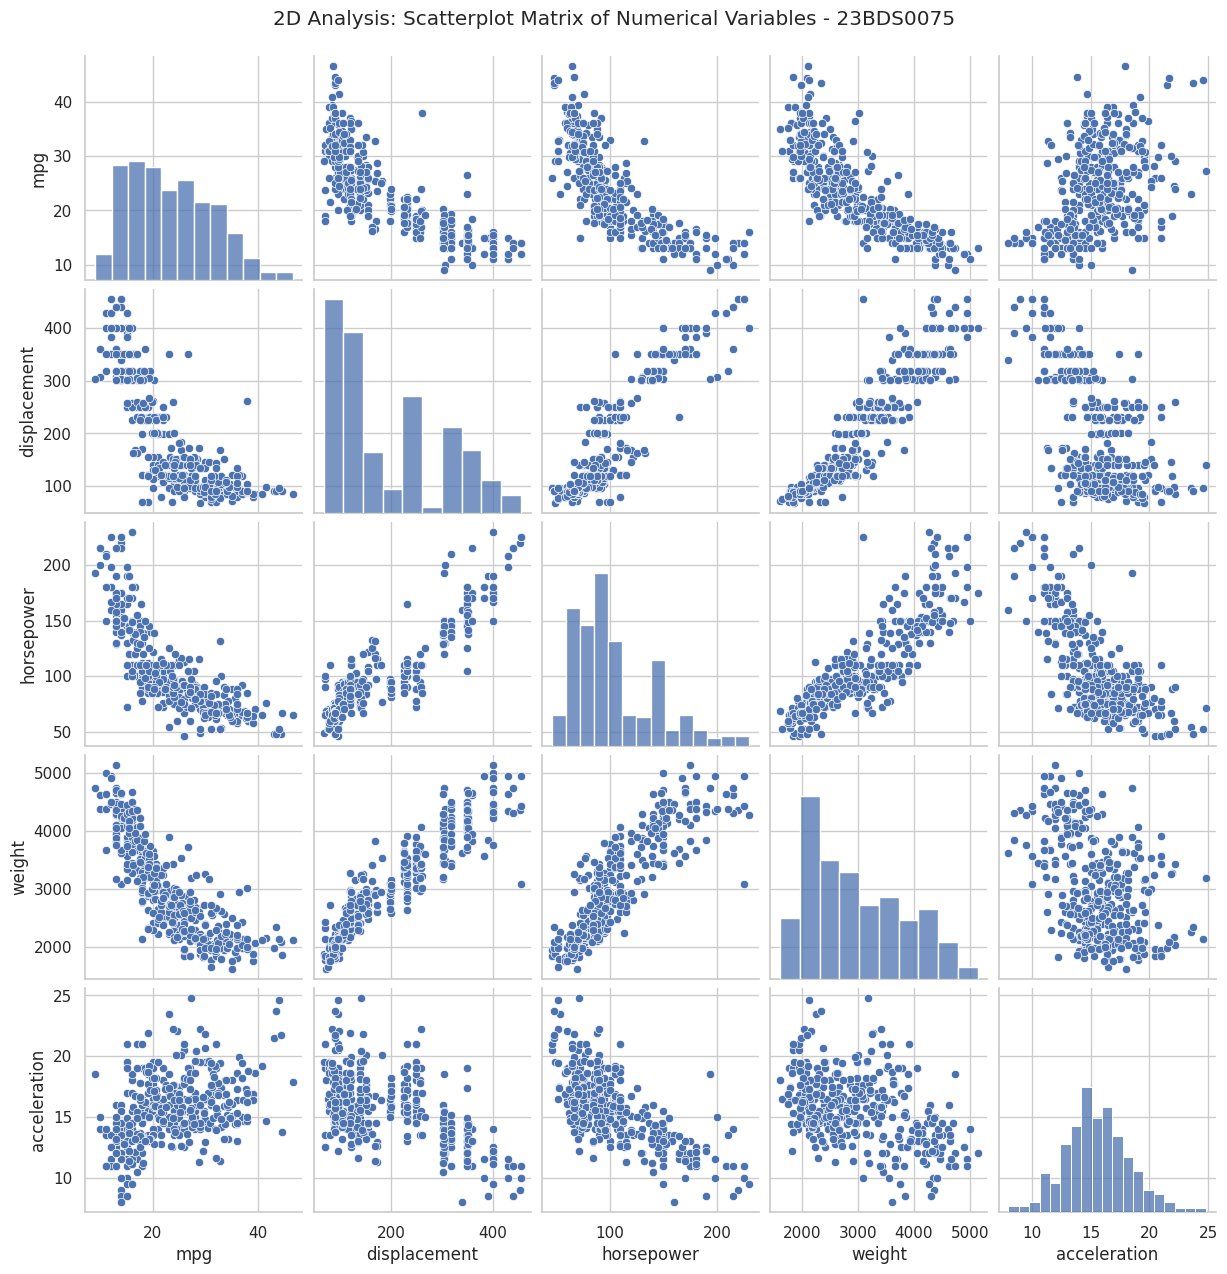


11. 3D / TRIVARIATE STATISTICAL ANALYSIS

Three-Variable Summary: Origin + Cylinders + MPG


,origin,cylinders,Count,Mean_MPG,Median_MPG,SD_MPG,Mean_Horsepower,Mean_Weight
0,Europe,3,0,NaN,NaN,NaN,NaN,NaN
1,Europe,4,61,28.107,27.00,6.291,78.311,2338.295
2,Europe,5,3,27.367,25.40,8.228,82.333,3103.333
3,Europe,6,4,20.100,16.75,7.074,113.500,3382.500
4,Europe,8,0,NaN,NaN,NaN,NaN,NaN
5,Japan,3,4,20.550,20.25,2.565,99.250,2398.500
6,Japan,4,69,31.596,32.00,5.436,75.580,2153.493
7,Japan,5,0,NaN,NaN,NaN,NaN,NaN
8,Japan,6,6,23.883,23.10,4.952,115.833,2882.000
9,Japan,8,0,NaN,NaN,NaN,NaN,NaN


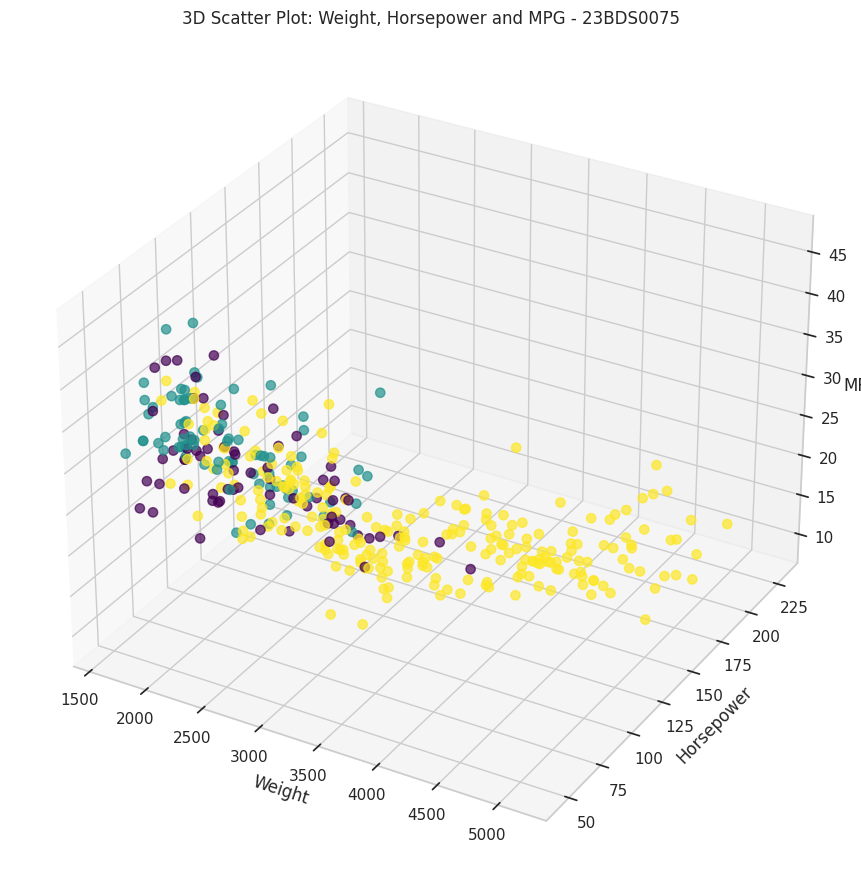


Multiple Linear Regression: MPG ~ Weight + Horsepower
                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.706
Model:                            OLS   Adj. R-squared:                  0.705
Method:                 Least Squares   F-statistic:                     467.9
Date:                Fri, 25 Sep 2026   Prob (F-statistic):          3.06e-104
Time:                        14:57:22   Log-Likelihood:                -1121.0
No. Observations:                 392   AIC:                             2248.
Df Residuals:                     389   BIC:                             2260.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------

,sum_sq,df,F,PR(>F)
C(origin),100.584322,2.0,2.444375,1.187727e-01
C(cylinders),33747.958901,4.0,410.067281,6.344470e-96
C(origin):C(cylinders),1122.633226,8.0,6.820489,4.132099e-06
Residual,7880.089961,383.0,NaN,NaN


In [18]:
# ================================================================
# PHASE 2
# 1D, 2D AND 3D STATISTICAL ANALYSIS
# K-MEANS AND HIERARCHICAL CLUSTERING
# ================================================================

# RAISA JOSE
# 23BDS0075

# ------------------------------------------------
# 8. IMPORT ADDITIONAL LIBRARIES
# ------------------------------------------------

from scipy import stats
from scipy.stats import (
    pearsonr,
    spearmanr,
    chi2_contingency,
    f_oneway
)

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples
)
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import (
    linkage,
    dendrogram,
    fcluster
)

from scipy.spatial.distance import pdist

import statsmodels.api as sm
import statsmodels.formula.api as smf

from statsmodels.stats.multicomp import pairwise_tukeyhsd

from mpl_toolkits.mplot3d import Axes3D

import warnings
warnings.filterwarnings("ignore")


# Work on a separate copy so Phase 1 is unchanged
df_phase2 = df_clean.copy()


print("\n" + "=" * 75)
print("PHASE 2 - STATISTICAL ANALYSIS AND CLUSTERING")
print("=" * 75)


# ================================================================
# 9. 1D / UNIVARIATE STATISTICAL ANALYSIS
# ================================================================

print("\n" + "=" * 75)
print("9. 1D / UNIVARIATE STATISTICAL ANALYSIS")
print("=" * 75)


# ------------------------------------------------
# 9.1 Select Numerical Variables
# ------------------------------------------------

numeric_1d_cols = [
    'mpg',
    'displacement',
    'horsepower',
    'weight',
    'acceleration',
    'year',
    'weight_per_hp'
]

numeric_1d = df_phase2[numeric_1d_cols].copy()

print("\nNumerical Variables:")
print(numeric_1d_cols)


# ------------------------------------------------
# 9.2 Detailed Descriptive Statistics
# ------------------------------------------------

def calculate_mode(series):
    mode_values = series.mode()

    if len(mode_values) > 0:
        return mode_values.iloc[0]

    return np.nan


one_d_statistics = pd.DataFrame({

    'Variable': numeric_1d_cols,

    'Count': [
        numeric_1d[col].count()
        for col in numeric_1d_cols
    ],

    'Mean': [
        numeric_1d[col].mean()
        for col in numeric_1d_cols
    ],

    'Median': [
        numeric_1d[col].median()
        for col in numeric_1d_cols
    ],

    'Mode': [
        calculate_mode(numeric_1d[col])
        for col in numeric_1d_cols
    ],

    'Minimum': [
        numeric_1d[col].min()
        for col in numeric_1d_cols
    ],

    'Q1': [
        numeric_1d[col].quantile(0.25)
        for col in numeric_1d_cols
    ],

    'Q3': [
        numeric_1d[col].quantile(0.75)
        for col in numeric_1d_cols
    ],

    'Maximum': [
        numeric_1d[col].max()
        for col in numeric_1d_cols
    ],

    'Range': [
        numeric_1d[col].max() -
        numeric_1d[col].min()

        for col in numeric_1d_cols
    ],

    'Variance': [
        numeric_1d[col].var()
        for col in numeric_1d_cols
    ],

    'Standard_Deviation': [
        numeric_1d[col].std()
        for col in numeric_1d_cols
    ],

    'IQR': [
        stats.iqr(
            numeric_1d[col],
            nan_policy='omit'
        )
        for col in numeric_1d_cols
    ],

    'Skewness': [
        stats.skew(
            numeric_1d[col].dropna(),
            bias=False
        )
        for col in numeric_1d_cols
    ],

    'Kurtosis': [
        stats.kurtosis(
            numeric_1d[col].dropna(),
            bias=False
        )
        for col in numeric_1d_cols
    ]
})


print("\nDetailed 1D Descriptive Statistics:")
display(
    one_d_statistics.round(3)
)


# ------------------------------------------------
# 9.3 Coefficient of Variation
# ------------------------------------------------

coefficient_of_variation = pd.DataFrame({

    'Variable':
        numeric_1d_cols,

    'CV_Percentage': [

        (
            numeric_1d[col].std()
            /
            numeric_1d[col].mean()
        ) * 100

        for col in numeric_1d_cols
    ]

})


print("\nCoefficient of Variation (%):")
display(
    coefficient_of_variation.round(3)
)


# ------------------------------------------------
# 9.4 Quantile / Percentile Analysis
# ------------------------------------------------

quantile_table = numeric_1d.quantile(
    [
        0,
        0.10,
        0.25,
        0.50,
        0.75,
        0.90,
        1
    ]
).T


quantile_table.columns = [
    'Minimum',
    '10%',
    '25%',
    '50%',
    '75%',
    '90%',
    'Maximum'
]


print("\nQuantile Table:")
display(
    quantile_table.round(3)
)


# ------------------------------------------------
# 9.5 Origin Frequency / Relative Frequency
# ------------------------------------------------

origin_frequency = (
    df_phase2['origin']
    .value_counts()
    .sort_index()
)

origin_relative = (
    df_phase2['origin']
    .value_counts(normalize=True)
    .sort_index()
)


origin_frequency_table = pd.DataFrame({

    'Frequency':
        origin_frequency,

    'Relative_Frequency':
        origin_relative,

    'Percentage':
        origin_relative * 100

})


print("\nOrigin Frequency Distribution:")
display(
    origin_frequency_table.round(3)
)


# ------------------------------------------------
# 9.6 Cylinder Frequency / Relative Frequency
# ------------------------------------------------

cylinder_frequency = (
    df_phase2['cylinders']
    .value_counts()
    .sort_index()
)

cylinder_relative = (
    df_phase2['cylinders']
    .value_counts(normalize=True)
    .sort_index()
)


cylinder_frequency_table = pd.DataFrame({

    'Frequency':
        cylinder_frequency,

    'Relative_Frequency':
        cylinder_relative,

    'Percentage':
        cylinder_relative * 100

})


print("\nCylinder Frequency Distribution:")
display(
    cylinder_frequency_table.round(3)
)


# ------------------------------------------------
# 9.7 Horsepower Boxplot
# ------------------------------------------------

plt.figure(figsize=(9, 6))

sns.boxplot(
    y=df_phase2['horsepower']
)

plt.title(
    "1D Analysis: Horsepower Boxplot - 23BDS0075"
)

plt.ylabel("Horsepower")

plt.tight_layout()
plt.show()


# ------------------------------------------------
# 9.8 Acceleration Density Plot
# ------------------------------------------------
# Phase 1 used Weight for density.
# This uses Acceleration instead.

plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=df_phase2,
    x='acceleration',
    fill=True
)

plt.title(
    "1D Analysis: Density of Acceleration - 23BDS0075"
)

plt.xlabel("Acceleration")
plt.ylabel("Density")

plt.tight_layout()
plt.show()


# ------------------------------------------------
# 9.9 IQR Outlier Counts
# ------------------------------------------------

def count_iqr_outliers(series):

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)

    return (
        (series < lower_bound)
        |
        (series > upper_bound)
    ).sum()


outlier_summary = pd.DataFrame({

    'Variable':
        numeric_1d_cols,

    'Number_of_IQR_Outliers': [

        count_iqr_outliers(
            numeric_1d[col]
        )

        for col in numeric_1d_cols
    ]

})


print("\nIQR Outlier Summary:")
display(
    outlier_summary
)


# Outlier count visualization
plt.figure(figsize=(11, 6))

sns.barplot(
    data=outlier_summary,
    x='Variable',
    y='Number_of_IQR_Outliers'
)

plt.title(
    "Number of IQR Outliers by Variable - 23BDS0075"
)

plt.xlabel("Variable")
plt.ylabel("Number of Outliers")

plt.xticks(
    rotation=35
)

plt.tight_layout()
plt.show()


# ================================================================
# 10. 2D / BIVARIATE STATISTICAL ANALYSIS
# ================================================================

print("\n" + "=" * 75)
print("10. 2D / BIVARIATE STATISTICAL ANALYSIS")
print("=" * 75)


# ------------------------------------------------
# 10.1 Covariance Matrix
# ------------------------------------------------

covariance_matrix = numeric_1d.cov()

print("\nCovariance Matrix:")
display(
    covariance_matrix.round(2)
)


# ------------------------------------------------
# 10.2 Spearman Correlation Matrix
# ------------------------------------------------

spearman_matrix = numeric_1d.corr(
    method='spearman'
)

print("\nSpearman Correlation Matrix:")
display(
    spearman_matrix.round(3)
)


plt.figure(figsize=(11, 8))

sns.heatmap(
    spearman_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    square=True
)

plt.title(
    "2D Analysis: Spearman Correlation Matrix - 23BDS0075"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------
# 10.3 Pearson Correlation Significance Test
# MPG vs Weight
# ------------------------------------------------

pearson_r, pearson_p = pearsonr(
    df_phase2['mpg'],
    df_phase2['weight']
)

print(
    "\nPearson Correlation Test: MPG vs Weight"
)

print(
    "Correlation Coefficient:",
    round(pearson_r, 4)
)

print(
    "P-value:",
    pearson_p
)


# ------------------------------------------------
# 10.4 Spearman Correlation Significance Test
# MPG vs Horsepower
# ------------------------------------------------

spearman_r, spearman_p = spearmanr(
    df_phase2['mpg'],
    df_phase2['horsepower']
)

print(
    "\nSpearman Correlation Test: MPG vs Horsepower"
)

print(
    "Correlation Coefficient:",
    round(spearman_r, 4)
)

print(
    "P-value:",
    spearman_p
)


# ------------------------------------------------
# 10.5 New Scatter Relationship
# Horsepower vs MPG
# ------------------------------------------------

plt.figure(figsize=(10, 6))

sns.regplot(
    data=df_phase2,
    x='horsepower',
    y='mpg',
    scatter_kws={
        'alpha': 0.6
    }
)

plt.title(
    "2D Analysis: Horsepower vs MPG with Regression - 23BDS0075"
)

plt.xlabel("Horsepower")
plt.ylabel("MPG")

plt.tight_layout()
plt.show()


# ------------------------------------------------
# 10.6 Simple Linear Regression
# ------------------------------------------------

simple_model = smf.ols(
    'mpg ~ weight',
    data=df_phase2
).fit()


print(
    "\nSimple Linear Regression: MPG ~ Weight"
)

print(
    simple_model.summary()
)


# ------------------------------------------------
# 10.7 Residual Analysis
# ------------------------------------------------

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=simple_model.fittedvalues,
    y=simple_model.resid
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.title(
    "Regression Residual Plot: MPG Predicted by Weight - 23BDS0075"
)

plt.xlabel(
    "Fitted MPG"
)

plt.ylabel(
    "Residuals"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------
# 10.8 Grouped MPG Statistics by Origin
# ------------------------------------------------

mpg_by_origin = (
    df_phase2
    .groupby(
        'origin',
        observed=False
    )['mpg']
    .agg(
        Count='count',
        Mean='mean',
        Median='median',
        Standard_Deviation='std',
        Minimum='min',
        Maximum='max'
    )
    .reset_index()
)


print(
    "\nMPG Statistics by Origin:"
)

display(
    mpg_by_origin.round(3)
)


# ------------------------------------------------
# 10.9 Grouped MPG Statistics by Cylinders
# ------------------------------------------------

mpg_by_cylinders = (
    df_phase2
    .groupby(
        'cylinders',
        observed=False
    )['mpg']
    .agg(
        Count='count',
        Mean='mean',
        Median='median',
        Standard_Deviation='std',
        Minimum='min',
        Maximum='max'
    )
    .reset_index()
)


print(
    "\nMPG Statistics by Cylinder Count:"
)

display(
    mpg_by_cylinders.round(3)
)


# ------------------------------------------------
# 10.10 Two-Way Frequency Table
# Origin vs Cylinders
# ------------------------------------------------

origin_cylinder_table = pd.crosstab(
    df_phase2['origin'],
    df_phase2['cylinders']
)


print(
    "\nTwo-Way Frequency Table: Origin x Cylinders"
)

display(
    origin_cylinder_table
)


origin_cylinder_percentage = pd.crosstab(

    df_phase2['origin'],

    df_phase2['cylinders'],

    normalize='index'

) * 100


print(
    "\nRow-wise Percentage Table:"
)

display(
    origin_cylinder_percentage.round(2)
)


# ------------------------------------------------
# 10.11 Chi-Square Test of Independence
# ------------------------------------------------

chi2, chi_p, dof, expected = chi2_contingency(
    origin_cylinder_table
)


print(
    "\nChi-Square Test: Origin vs Cylinders"
)

print(
    "Chi-Square Statistic:",
    round(chi2, 4)
)

print(
    "Degrees of Freedom:",
    dof
)

print(
    "P-value:",
    chi_p
)


expected_df = pd.DataFrame(

    expected,

    index=
        origin_cylinder_table.index,

    columns=
        origin_cylinder_table.columns

)


print(
    "\nExpected Frequencies:"
)

display(
    expected_df.round(2)
)


# ------------------------------------------------
# 10.12 Cramer's V
# Strength of categorical association
# ------------------------------------------------

n = origin_cylinder_table.values.sum()

minimum_dimension = min(
    origin_cylinder_table.shape
) - 1

cramers_v = np.sqrt(
    chi2 /
    (
        n *
        minimum_dimension
    )
)


print(
    "\nCramer's V:",
    round(cramers_v, 4)
)


# ------------------------------------------------
# 10.13 One-Way ANOVA
# Does MPG differ among origins?
# ------------------------------------------------

origin_groups = [

    group['mpg'].values

    for _, group in
    df_phase2.groupby(
        'origin',
        observed=False
    )
]


anova_result = f_oneway(
    *origin_groups
)


print(
    "\nOne-Way ANOVA: MPG by Origin"
)

print(
    "F-statistic:",
    round(
        anova_result.statistic,
        4
    )
)

print(
    "P-value:",
    anova_result.pvalue
)


# Full ANOVA table

anova_model = smf.ols(
    'mpg ~ C(origin)',
    data=df_phase2
).fit()


anova_table = sm.stats.anova_lm(
    anova_model,
    typ=2
)


print(
    "\nANOVA Table:"
)

display(
    anova_table
)


# ------------------------------------------------
# 10.14 Tukey HSD Post-Hoc Test
# ------------------------------------------------

tukey_result = pairwise_tukeyhsd(

    endog=
        df_phase2['mpg'],

    groups=
        df_phase2['origin'],

    alpha=0.05

)


print(
    "\nTukey HSD Post-Hoc Test:"
)

print(
    tukey_result
)


# ------------------------------------------------
# 10.15 Scatterplot Matrix
# ------------------------------------------------

pairs_data = df_phase2[
    [
        'mpg',
        'displacement',
        'horsepower',
        'weight',
        'acceleration'
    ]
]


pair_plot = sns.pairplot(
    pairs_data
)


pair_plot.fig.suptitle(

    "2D Analysis: Scatterplot Matrix of Numerical Variables - 23BDS0075",

    y=1.02

)

plt.show()


# ================================================================
# 11. 3D / TRIVARIATE STATISTICAL ANALYSIS
# ================================================================

print("\n" + "=" * 75)
print("11. 3D / TRIVARIATE STATISTICAL ANALYSIS")
print("=" * 75)


# ------------------------------------------------
# 11.1 Three-Variable Grouped Statistics
# Origin + Cylinders -> MPG
# ------------------------------------------------

three_variable_summary = (

    df_phase2

    .groupby(
        [
            'origin',
            'cylinders'
        ],
        observed=False
    )

    .agg(

        Count=
            ('mpg', 'count'),

        Mean_MPG=
            ('mpg', 'mean'),

        Median_MPG=
            ('mpg', 'median'),

        SD_MPG=
            ('mpg', 'std'),

        Mean_Horsepower=
            ('horsepower', 'mean'),

        Mean_Weight=
            ('weight', 'mean')

    )

    .reset_index()

)


print(
    "\nThree-Variable Summary: Origin + Cylinders + MPG"
)

display(
    three_variable_summary.round(3)
)


# ------------------------------------------------
# 11.2 Actual 3D Scatter Plot
# Weight + Horsepower + MPG
# ------------------------------------------------

fig = plt.figure(
    figsize=(12, 9)
)

ax = fig.add_subplot(
    111,
    projection='3d'
)


origin_codes = pd.Categorical(
    df_phase2['origin']
).codes


scatter = ax.scatter(

    df_phase2['weight'],

    df_phase2['horsepower'],

    df_phase2['mpg'],

    c=origin_codes,

    cmap='viridis',

    alpha=0.7,

    s=45

)


ax.set_xlabel(
    "Weight"
)

ax.set_ylabel(
    "Horsepower"
)

ax.set_zlabel(
    "MPG"
)


ax.set_title(
    "3D Scatter Plot: Weight, Horsepower and MPG - 23BDS0075"
)


plt.tight_layout()
plt.show()


# ------------------------------------------------
# 11.3 Multiple Linear Regression
# Three variables involved:
# MPG, Weight and Horsepower
# ------------------------------------------------

multiple_model = smf.ols(

    'mpg ~ weight + horsepower',

    data=df_phase2

).fit()


print(
    "\nMultiple Linear Regression: MPG ~ Weight + Horsepower"
)

print(
    multiple_model.summary()
)


# ------------------------------------------------
# 11.4 Extended Multiple Regression
# ------------------------------------------------

extended_model = smf.ols(

    'mpg ~ displacement + '
    'horsepower + '
    'weight + '
    'acceleration + '
    'year + '
    'C(origin)',

    data=df_phase2

).fit()


print(
    "\nExtended Multiple Linear Regression:"
)

print(
    extended_model.summary()
)


# ------------------------------------------------
# 11.5 Two-Way ANOVA
# MPG based on Origin and Cylinders
# ------------------------------------------------

two_way_model = smf.ols(

    'mpg ~ C(origin) * C(cylinders)',

    data=df_phase2

).fit()


two_way_anova = sm.stats.anova_lm(

    two_way_model,

    typ=2

)


print(
    "\nTwo-Way ANOVA: MPG ~ Origin * Cylinders"
)

display(
    two_way_anova
)




12. DATA PREPARATION FOR CLUSTERING

Features Used for Clustering:
['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration']

First Six Records:


,mpg,cylinders,displacement,horsepower,weight,acceleration
0,18.0,8.0,307.0,130.0,3504.0,12.0
1,15.0,8.0,350.0,165.0,3693.0,11.5
2,18.0,8.0,318.0,150.0,3436.0,11.0
3,16.0,8.0,304.0,150.0,3433.0,12.0
4,17.0,8.0,302.0,140.0,3449.0,10.5



Missing Values:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
dtype: int64

First Six Standardized Records:


,mpg,cylinders,displacement,horsepower,weight,acceleration
0,-0.698638,1.483947,1.077290,0.664133,0.620540,-1.285258
1,-1.083498,1.483947,1.488732,1.574594,0.843334,-1.466724
2,-0.698638,1.483947,1.182542,1.184397,0.540382,-1.648189
3,-0.955212,1.483947,1.048584,1.184397,0.536845,-1.285258
4,-0.826925,1.483947,1.029447,0.924265,0.555706,-1.829655



Means After Standardization:
mpg             0.0
cylinders      -0.0
displacement   -0.0
horsepower     -0.0
weight         -0.0
acceleration    0.0
dtype: float64

Standard Deviations After Standardization:
mpg             1.0
cylinders       1.0
displacement    1.0
horsepower      1.0
weight          1.0
acceleration    1.0
dtype: float64

13. K-MEANS CLUSTERING

WCSS Values:


,K,WCSS
0,1,2352.000
1,2,927.695
2,3,596.525
3,4,482.108
4,5,416.494
5,6,360.182
6,7,326.801
7,8,296.006
8,9,278.722
9,10,262.253


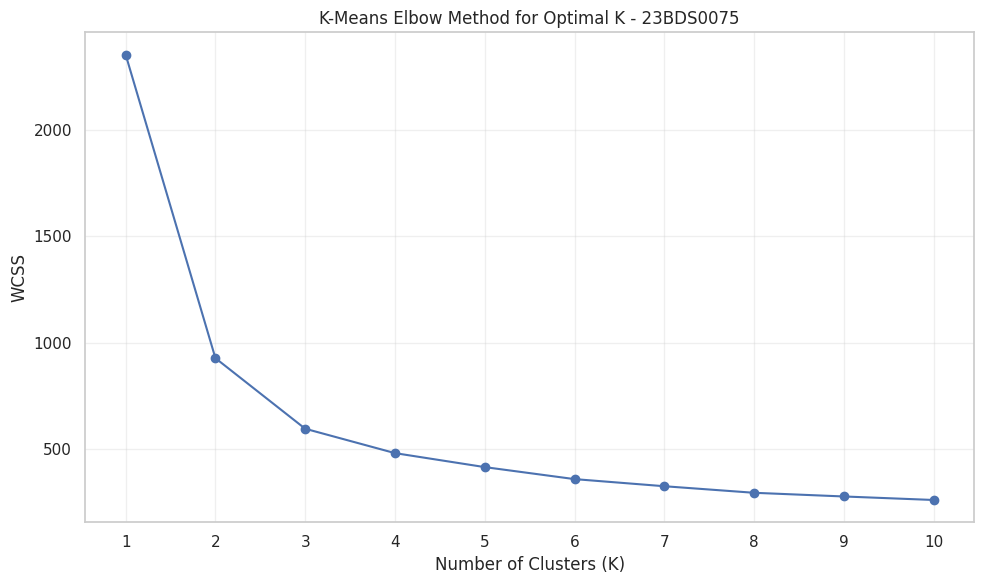


Approximate Optimal K from Elbow Method: 3

Silhouette Scores:


,K,Average_Silhouette
0,2,0.5450
1,3,0.4423
2,4,0.3816
3,5,0.3698
4,6,0.3319
5,7,0.3068
6,8,0.2964
7,9,0.2799
8,10,0.2721


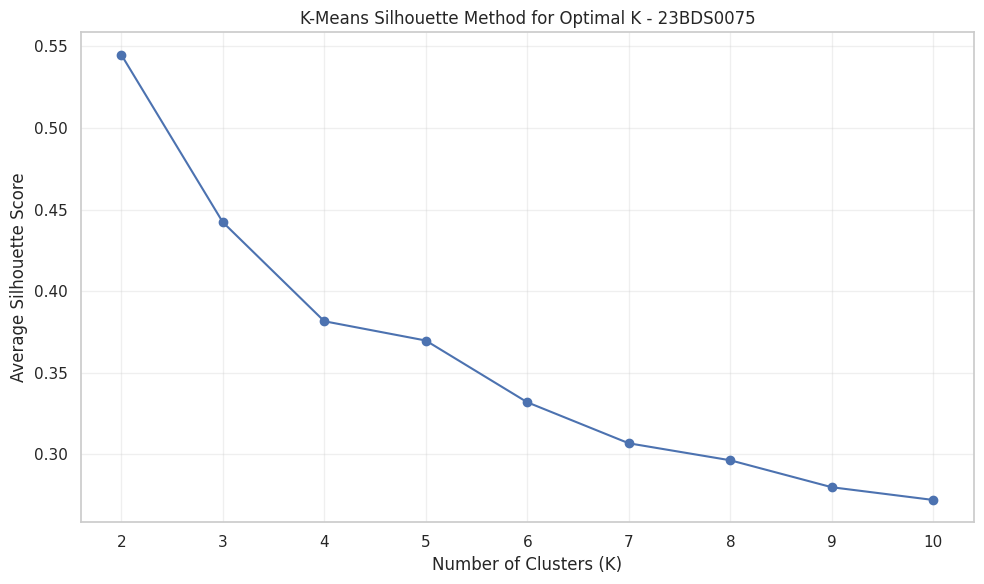


Best K According to Silhouette Analysis: 2

Final K-Means Model:
KMeans(n_clusters=3, n_init=50, random_state=123)

Number of Cars in Each K-Means Cluster:


,Count
1,93
2,202
3,97



Standardized K-Means Cluster Centers:


,mpg,cylinders,displacement,horsepower,weight,acceleration
Cluster 1,-0.466,0.335,0.228,-0.069,0.293,0.308
Cluster 2,0.764,-0.861,-0.811,-0.684,-0.795,0.364
Cluster 3,-1.144,1.472,1.470,1.491,1.375,-1.053



K-Means Cluster Profiles in Original Units:


...


K-Means Cluster vs Actual Origin:


origin,Europe,Japan,USA
KMeans_Cluster,,,
1,9,6,78
2,59,73,70
3,0,0,97



Row-wise Percentages:


origin,Europe,Japan,USA
KMeans_Cluster,,,
1,9.68,6.45,83.87
2,29.21,36.14,34.65
3,0.00,0.00,100.00



PCA Variance Explained:
PC1: 79.80%
PC2: 12.14%


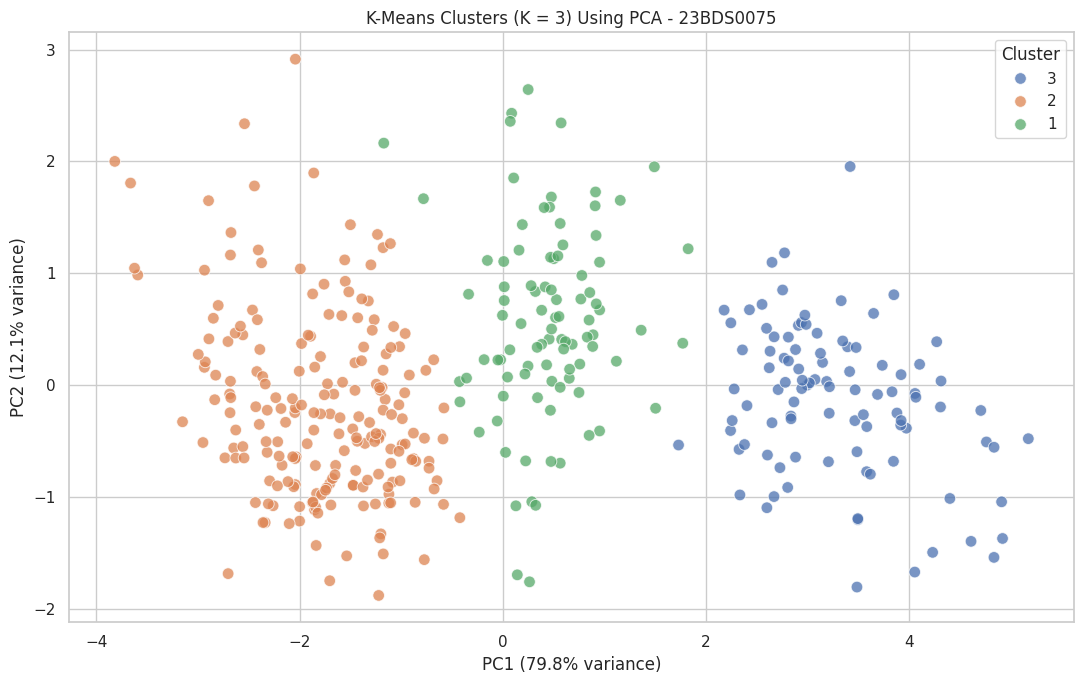


Average Silhouette Score of Final K-Means: 0.4423


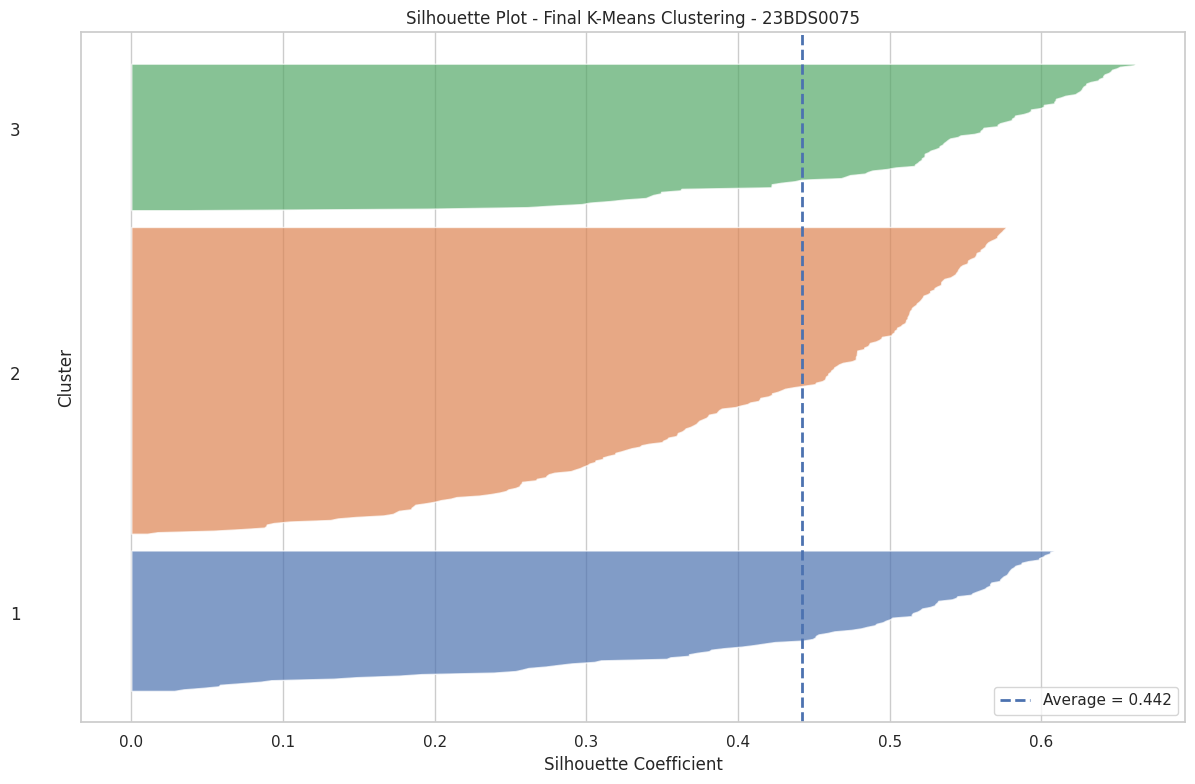


14. HIERARCHICAL CLUSTERING

First 20 Euclidean Distances:
[1.1086 0.648  0.5868 0.6221 2.4779 3.1484 3.0484 3.1751 2.2349 1.5137
 1.7592 1.458  3.0242 3.6532 2.4078 2.3531 2.6872 3.94   5.3634 4.0087]

Last 20 Euclidean Distances:
[1.5728 4.4365 0.7275 2.3047 2.4501 0.6619 3.7355 2.3098 0.7455 1.027
 4.121  1.6925 1.1444 1.4911 5.0491 3.1364 2.735  2.628  2.8823 0.5011]

Total Number of Pairwise Distances: 76636

First 10 Ward Linkage Operations:


,Cluster_1,Cluster_2,Distance,Sample_Count
0,18.0,29.0,0.000,2.0
1,179.0,196.0,0.036,2.0
2,336.0,382.0,0.061,2.0
3,173.0,195.0,0.073,2.0
4,264.0,277.0,0.077,2.0
5,174.0,255.0,0.089,2.0
6,14.0,271.0,0.095,2.0
7,349.0,350.0,0.122,2.0
8,333.0,351.0,0.128,2.0
9,125.0,167.0,0.129,2.0


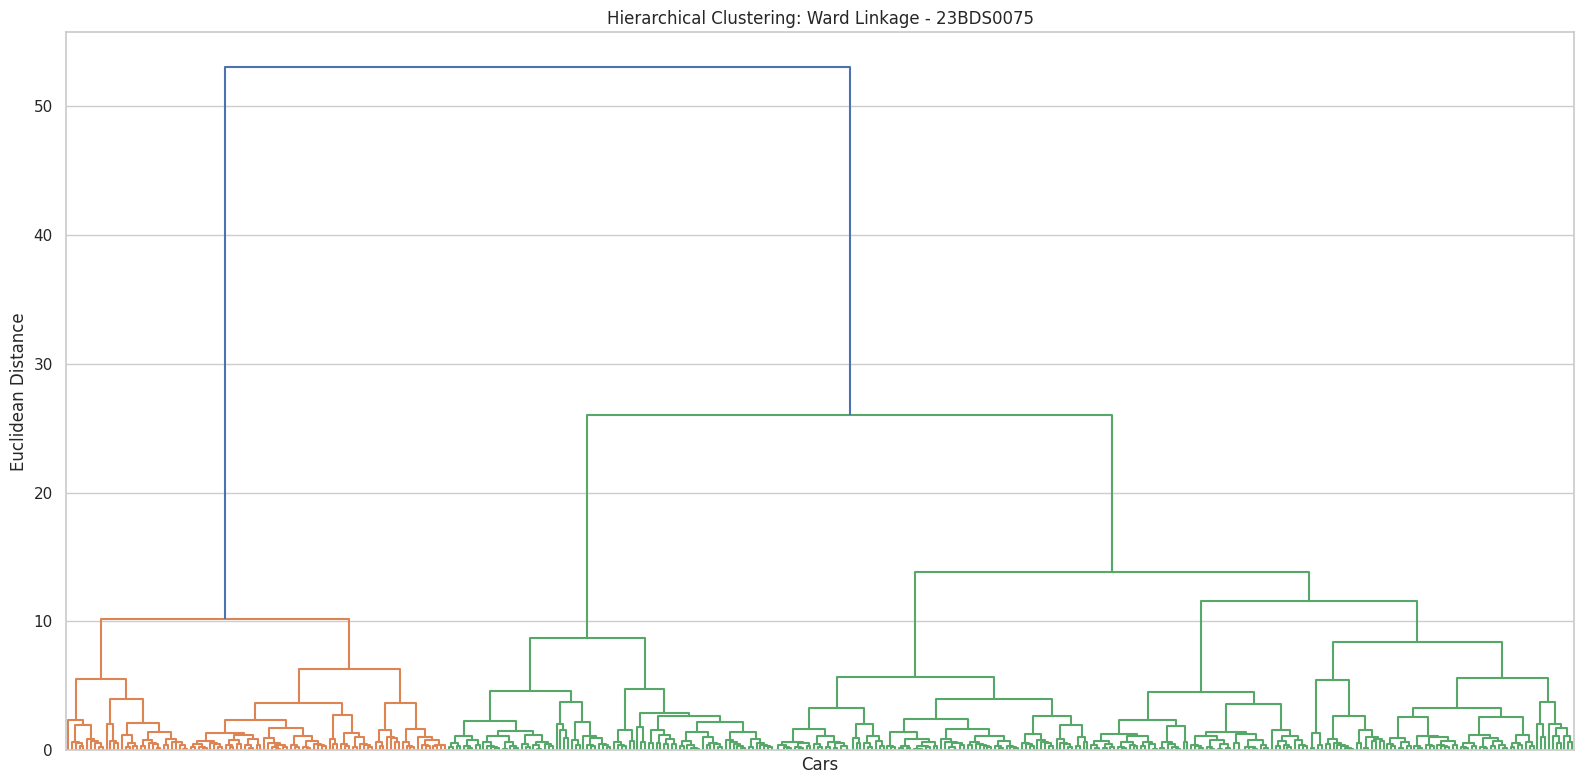

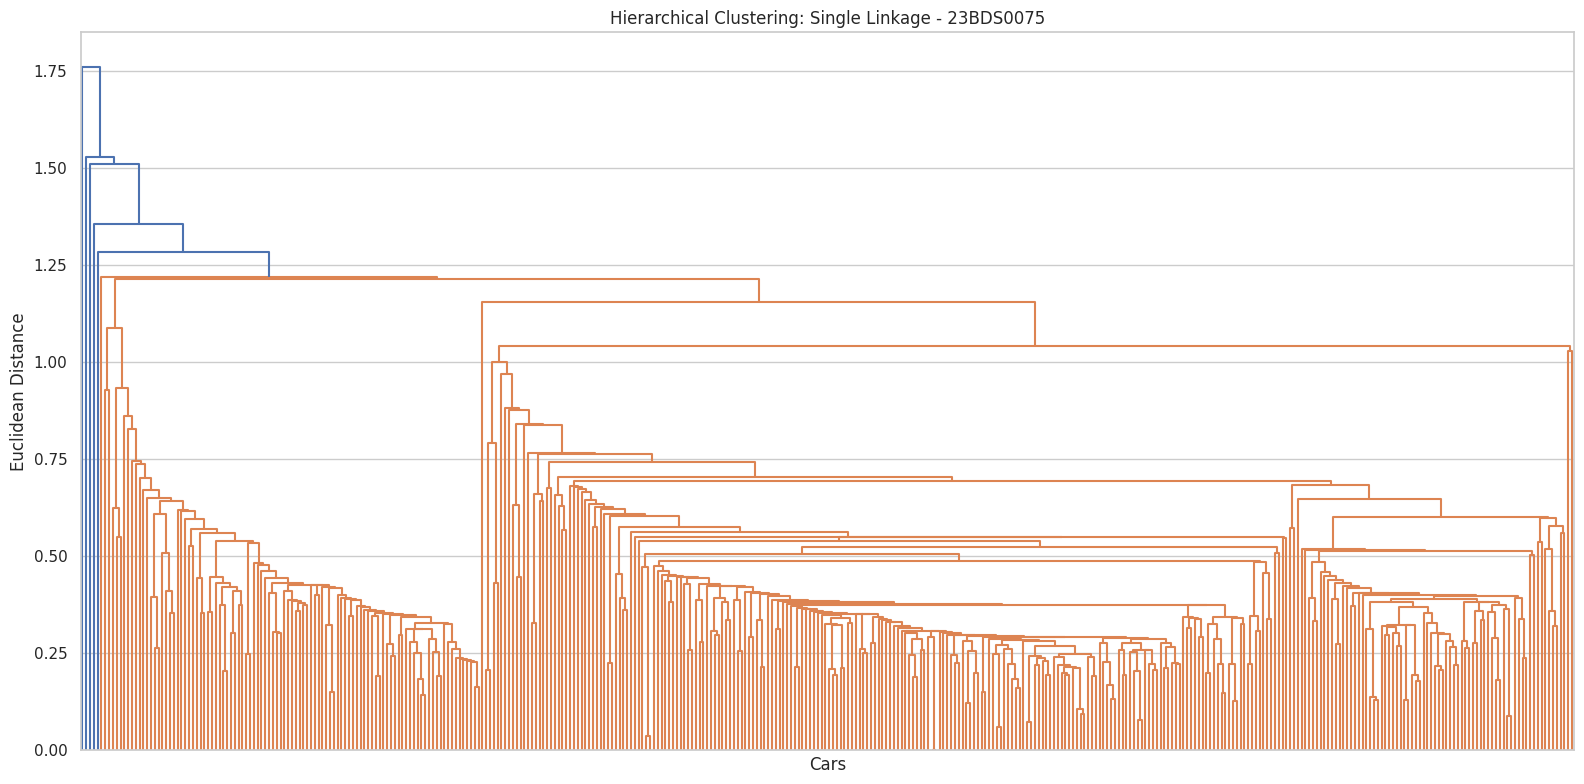

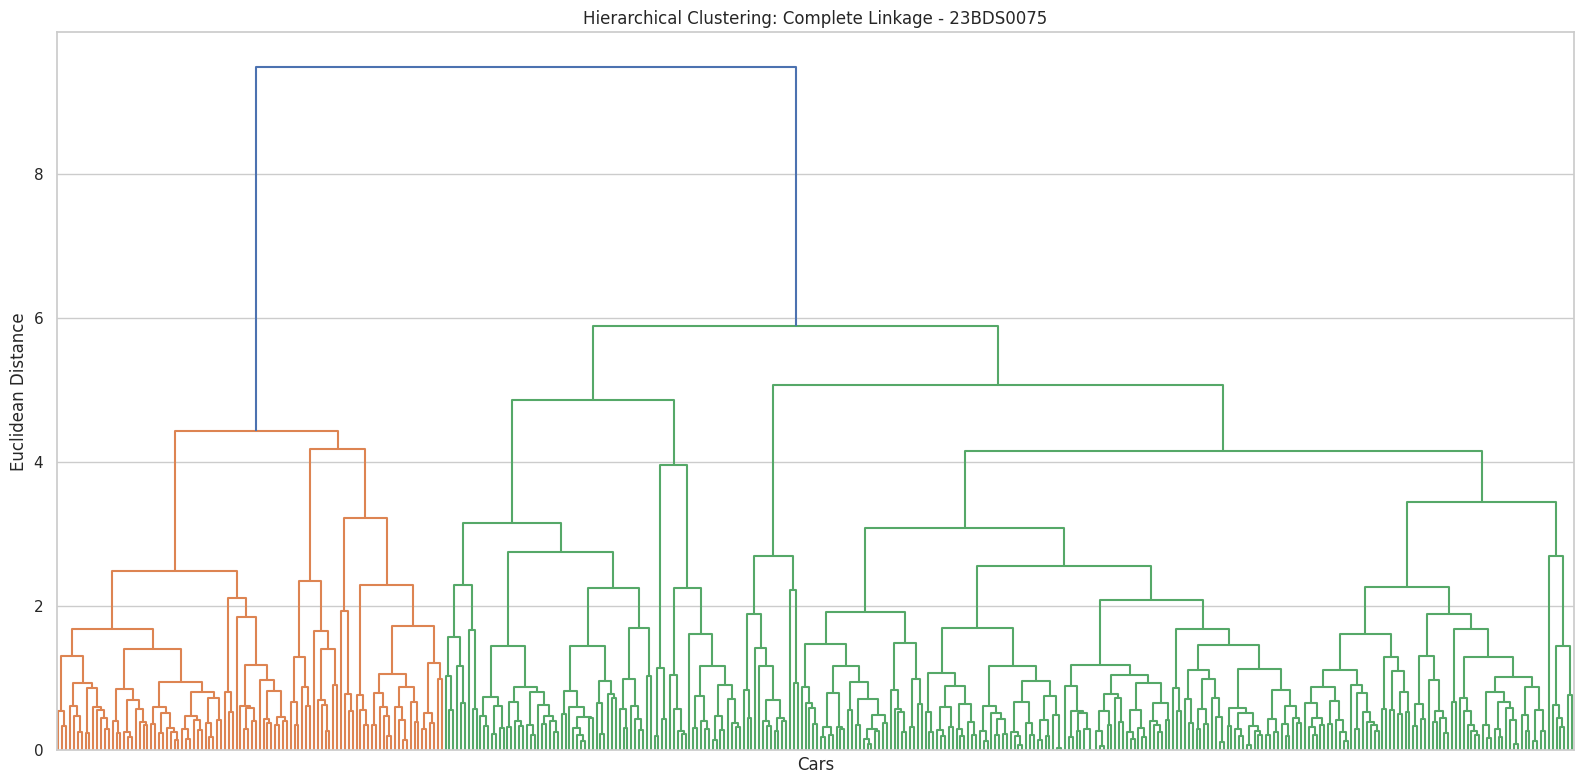

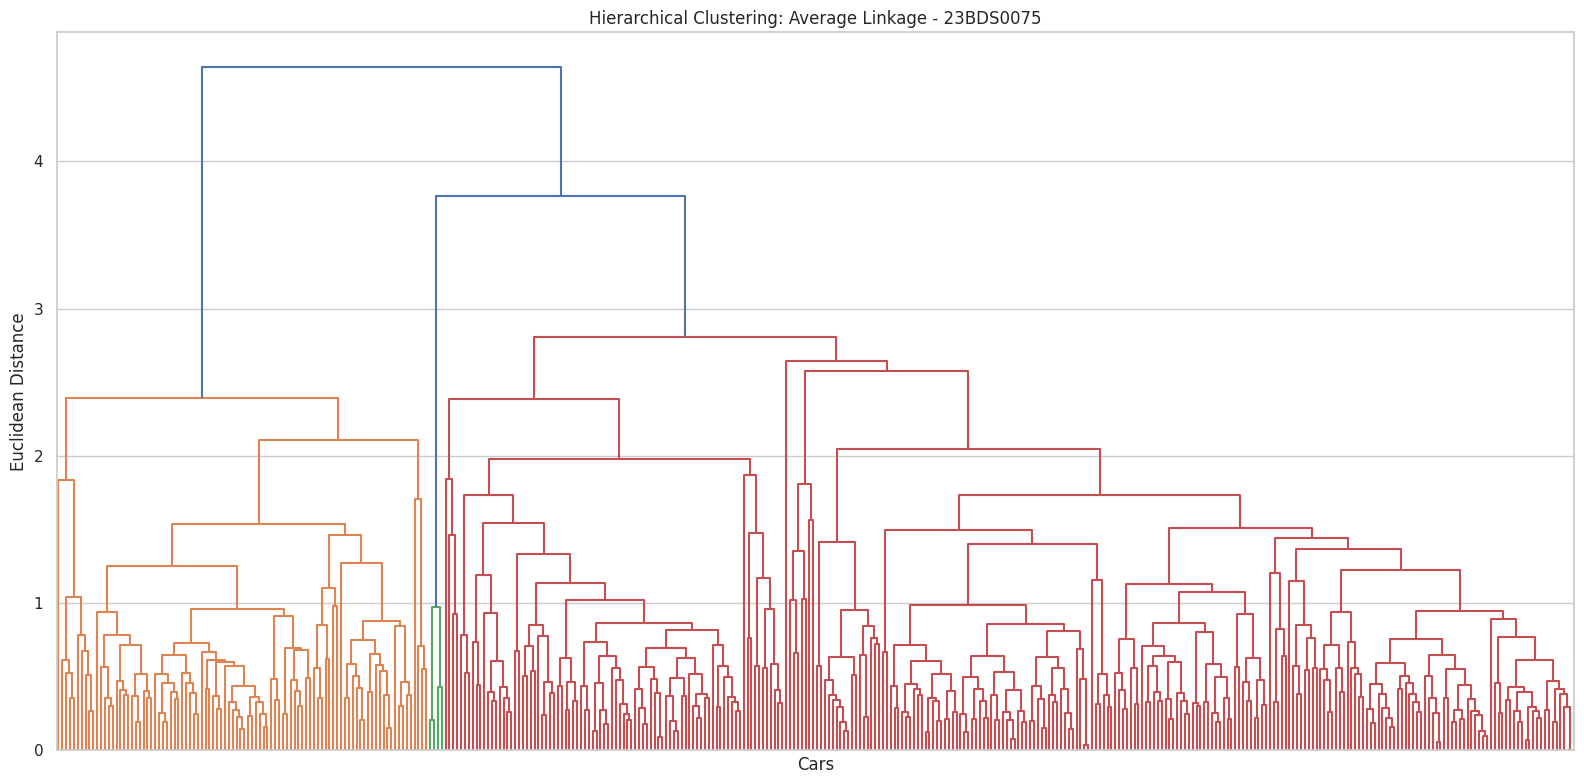


Number of Cars in Each Hierarchical Cluster:


,Count
1,99
2,85
3,208


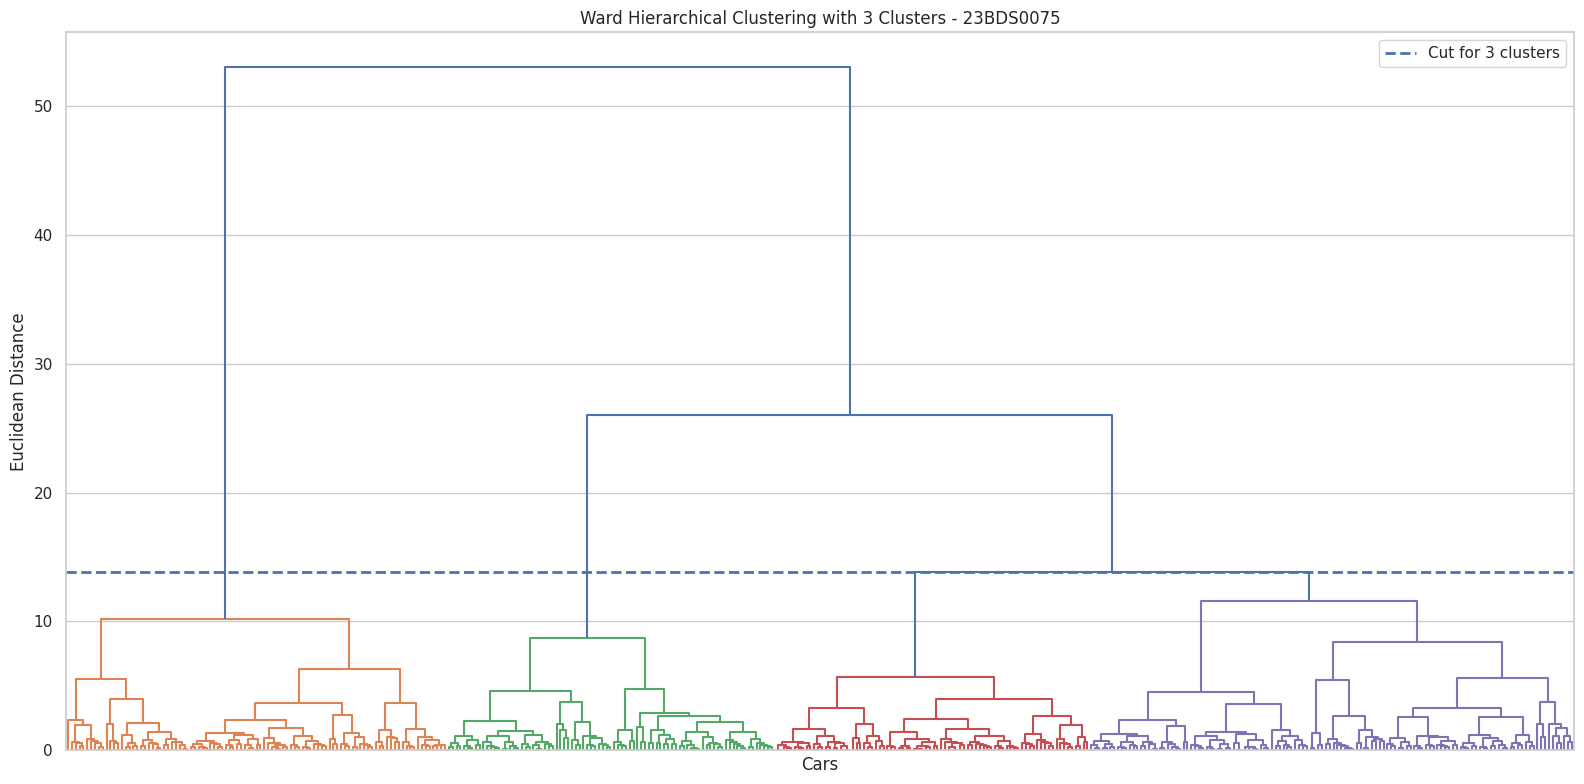


Hierarchical Cluster Profiles in Original Units:


,mpg,cylinders,displacement,horsepower,weight,acceleration
Cluster,,,,,,
1,14.65,8.00,346.63,160.35,4128.39,12.69
2,19.76,6.09,222.79,102.28,3231.84,16.35
3,29.14,4.01,110.37,78.76,2325.94,16.56



Hierarchical Cluster vs Actual Origin:


origin,Europe,Japan,USA
Hierarchical_Cluster,,,
1,0,0,99
2,3,6,76
3,65,73,70



Row-wise Percentages:


origin,Europe,Japan,USA
Hierarchical_Cluster,,,
1,0.00,0.00,100.00
2,3.53,7.06,89.41
3,31.25,35.10,33.65


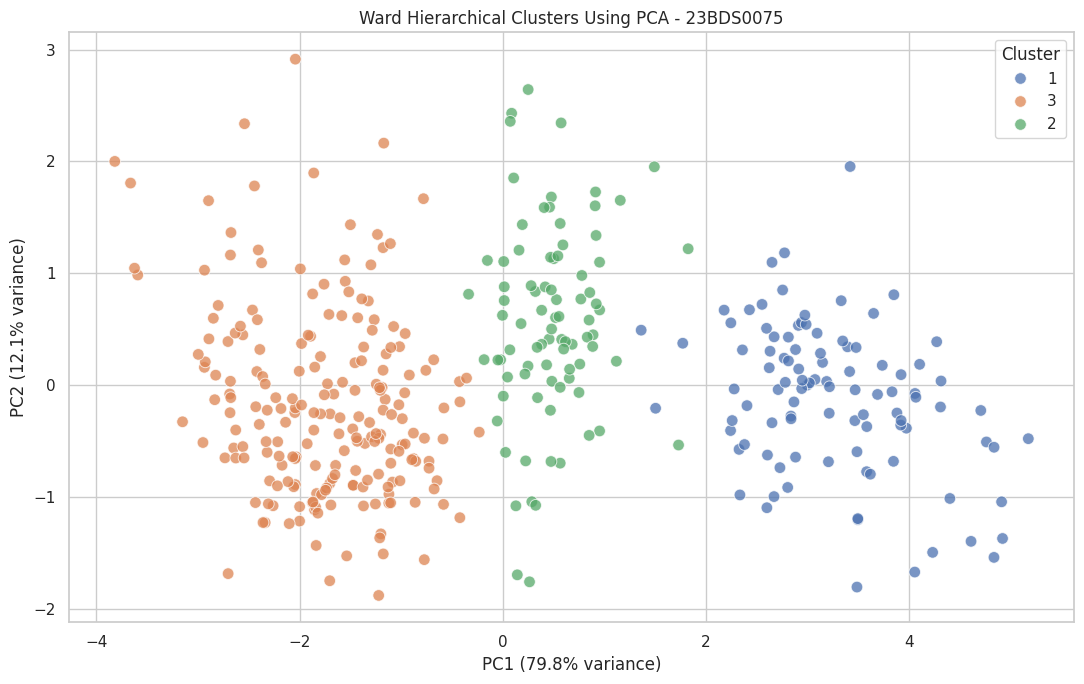


Average Silhouette Score of Ward Hierarchical Clustering: 0.4363


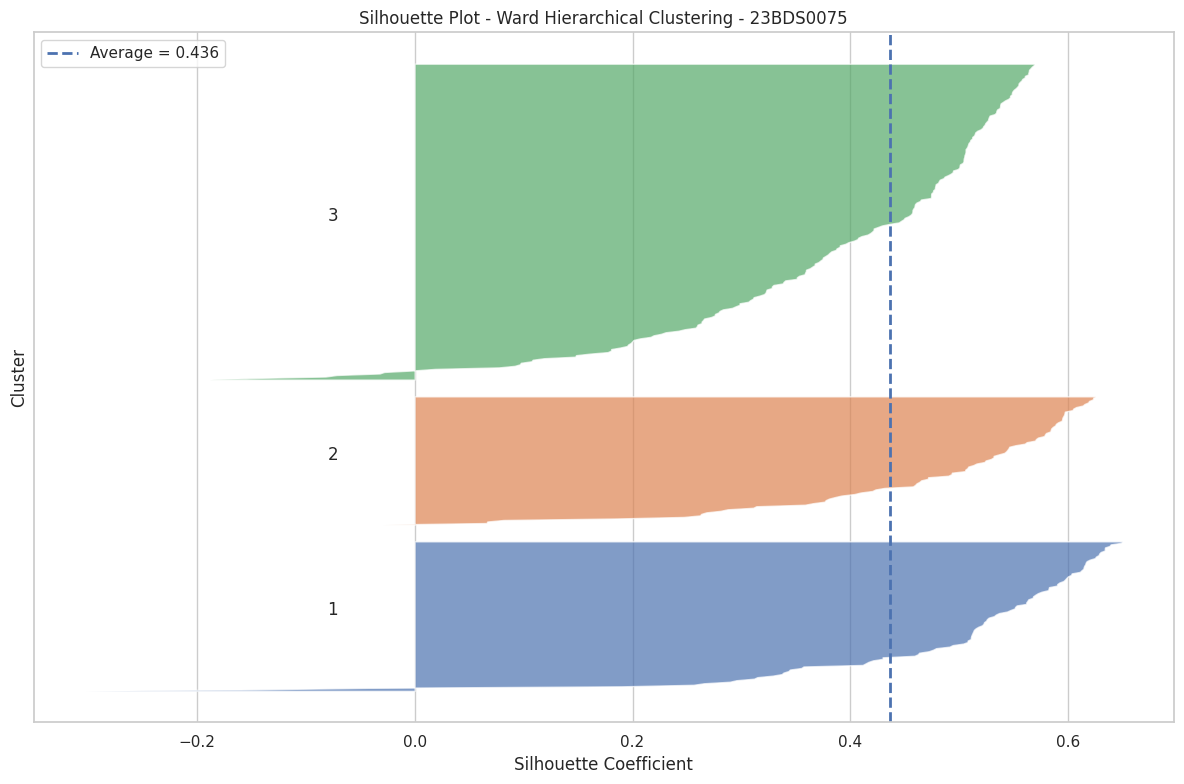


15. K-MEANS VS HIERARCHICAL CLUSTERING

K-Means vs Hierarchical Cluster Assignments:


Hierarchical Cluster,1,2,3
K-Means Cluster,,,
1,3,84,6
2,0,0,202
3,96,1,0



Clustering Quality Comparison:


,Method,Number_of_Clusters,Average_Silhouette
0,K-Means,3,0.4423
1,Hierarchical - Ward,3,0.4363


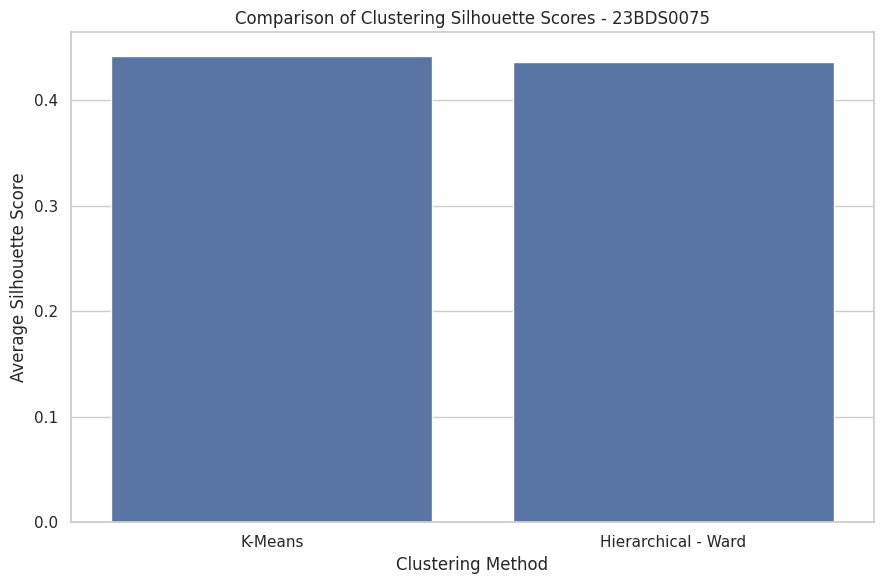


16. FINAL DATA WITH CLUSTER ASSIGNMENTS

First 10 Rows:


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name,weight_per_hp,KMeans_Cluster,Hierarchical_Cluster
0,18.0,8,307.0,130,3504,12.0,70,USA,chevrolet chevelle malibu,26.953846,3,1
1,15.0,8,350.0,165,3693,11.5,70,USA,buick skylark 320,22.381818,3,1
2,18.0,8,318.0,150,3436,11.0,70,USA,plymouth satellite,22.906667,3,1
3,16.0,8,304.0,150,3433,12.0,70,USA,amc rebel sst,22.886667,3,1
4,17.0,8,302.0,140,3449,10.5,70,USA,ford torino,24.635714,3,1
5,15.0,8,429.0,198,4341,10.0,70,USA,ford galaxie 500,21.924242,3,1
6,14.0,8,454.0,220,4354,9.0,70,USA,chevrolet impala,19.790909,3,1
7,14.0,8,440.0,215,4312,8.5,70,USA,plymouth fury iii,20.055814,3,1
8,14.0,8,455.0,225,4425,10.0,70,USA,pontiac catalina,19.666667,3,1
9,15.0,8,390.0,190,3850,8.5,70,USA,amc ambassador dpl,20.263158,3,1



Final Dataset Dimensions:
(392, 12)

Final Columns:
['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'year', 'origin', 'name', 'weight_per_hp', 'KMeans_Cluster', 'Hierarchical_Cluster']


In [20]:

# ================================================================
# 12. PREPARE DATA FOR CLUSTERING
# ================================================================

print("\n" + "=" * 75)
print("12. DATA PREPARATION FOR CLUSTERING")
print("=" * 75)



cluster_data = pd.DataFrame({

    'mpg':
        df_phase2['mpg'].astype(float),

    'cylinders':
        df_phase2['cylinders'].astype(float),

    'displacement':
        df_phase2['displacement'].astype(float),

    'horsepower':
        df_phase2['horsepower'].astype(float),

    'weight':
        df_phase2['weight'].astype(float),

    'acceleration':
        df_phase2['acceleration'].astype(float)

})


print(
    "\nFeatures Used for Clustering:"
)

print(
    cluster_data.columns.tolist()
)


print(
    "\nFirst Six Records:"
)

display(
    cluster_data.head()
)


print(
    "\nMissing Values:"
)

print(
    cluster_data.isnull().sum()
)


# ------------------------------------------------
# 12.1 Remove Zero-Variance Features
# ------------------------------------------------

non_zero_variance_cols = [

    col

    for col in cluster_data.columns

    if cluster_data[col].std() > 0

]


cluster_data = cluster_data[
    non_zero_variance_cols
]


# ------------------------------------------------
# 12.2 Standardization
# ------------------------------------------------

scaler = StandardScaler()


scaled_cluster_data = scaler.fit_transform(
    cluster_data
)


scaled_cluster_df = pd.DataFrame(

    scaled_cluster_data,

    columns=
        cluster_data.columns,

    index=
        cluster_data.index

)


print(
    "\nFirst Six Standardized Records:"
)

display(
    scaled_cluster_df.head()
)


print(
    "\nMeans After Standardization:"
)

print(
    scaled_cluster_df
    .mean()
    .round(5)
)


print(
    "\nStandard Deviations After Standardization:"
)

print(
    scaled_cluster_df
    .std(ddof=0)
    .round(5)
)


# ================================================================
# 13. K-MEANS CLUSTERING
# ================================================================

print("\n" + "=" * 75)
print("13. K-MEANS CLUSTERING")
print("=" * 75)


# ------------------------------------------------
# 13.1 WCSS for K = 1 to 10
# ------------------------------------------------

wcss = []


for k in range(1, 11):

    model = KMeans(

        n_clusters=k,

        random_state=123,

        n_init=25

    )

    model.fit(
        scaled_cluster_data
    )

    wcss.append(
        model.inertia_
    )


wcss_table = pd.DataFrame({

    'K':
        range(1, 11),

    'WCSS':
        wcss

})


print(
    "\nWCSS Values:"
)

display(
    wcss_table.round(3)
)


# ------------------------------------------------
# 13.2 Elbow Plot
# ------------------------------------------------

plt.figure(
    figsize=(10, 6)
)


plt.plot(

    range(1, 11),

    wcss,

    marker='o'

)


plt.xticks(
    range(1, 11)
)


plt.xlabel(
    "Number of Clusters (K)"
)

plt.ylabel(
    "WCSS"
)


plt.title(
    "K-Means Elbow Method for Optimal K - 23BDS0075"
)


plt.grid(
    alpha=0.3
)


plt.tight_layout()
plt.show()


# ------------------------------------------------
# 13.3 Automatic Approximate Elbow Detection
# ------------------------------------------------

x = np.arange(
    1,
    11
)

y = np.array(
    wcss
)


x1 = x[0]
y1 = y[0]

x2 = x[-1]
y2 = y[-1]


distance_from_line = (

    np.abs(

        (y2 - y1) * x

        -

        (x2 - x1) * y

        +

        x2 * y1

        -

        y2 * x1
    )

    /

    np.sqrt(

        (y2 - y1) ** 2

        +

        (x2 - x1) ** 2

    )

)


elbow_k = int(

    x[
        np.argmax(
            distance_from_line
        )
    ]

)


print(
    "\nApproximate Optimal K from Elbow Method:",
    elbow_k
)


# ------------------------------------------------
# 13.4 Silhouette Analysis for K = 2 to 10
# ------------------------------------------------

silhouette_scores = []


for k in range(2, 11):

    model = KMeans(

        n_clusters=k,

        random_state=123,

        n_init=25

    )


    labels = model.fit_predict(
        scaled_cluster_data
    )


    score = silhouette_score(

        scaled_cluster_data,

        labels

    )


    silhouette_scores.append(
        score
    )


silhouette_table = pd.DataFrame({

    'K':
        range(2, 11),

    'Average_Silhouette':
        silhouette_scores

})


print(
    "\nSilhouette Scores:"
)

display(
    silhouette_table.round(4)
)


plt.figure(
    figsize=(10, 6)
)


plt.plot(

    range(2, 11),

    silhouette_scores,

    marker='o'

)


plt.xticks(
    range(2, 11)
)


plt.xlabel(
    "Number of Clusters (K)"
)

plt.ylabel(
    "Average Silhouette Score"
)


plt.title(
    "K-Means Silhouette Method for Optimal K - 23BDS0075"
)


plt.grid(
    alpha=0.3
)


plt.tight_layout()
plt.show()


best_silhouette_k = (

    np.argmax(
        silhouette_scores
    )

    + 2

)


print(
    "\nBest K According to Silhouette Analysis:",
    best_silhouette_k
)


# ------------------------------------------------
# 13.5 Final K-Means Model
# ------------------------------------------------

optimal_k = elbow_k


final_kmeans = KMeans(

    n_clusters=
        optimal_k,

    random_state=
        123,

    n_init=
        50,

    max_iter=
        300

)


kmeans_labels = final_kmeans.fit_predict(
    scaled_cluster_data
)


kmeans_labels_display = (
    kmeans_labels + 1
)


print(
    "\nFinal K-Means Model:"
)

print(
    final_kmeans
)



# ------------------------------------------------
# 13.6 Cluster Counts
# ------------------------------------------------

kmeans_cluster_counts = (

    pd.Series(
        kmeans_labels_display
    )

    .value_counts()

    .sort_index()

)


print(
    "\nNumber of Cars in Each K-Means Cluster:"
)

display(
    kmeans_cluster_counts.rename(
        "Count"
    )
)


# ------------------------------------------------
# 13.7 Standardized Cluster Centers
# ------------------------------------------------

kmeans_centers_standardized = pd.DataFrame(

    final_kmeans.cluster_centers_,

    columns=
        cluster_data.columns,

    index=[

        f'Cluster {i}'

        for i in range(
            1,
            optimal_k + 1
        )

    ]

)


print(
    "\nStandardized K-Means Cluster Centers:"
)

display(
    kmeans_centers_standardized.round(3)
)


# ------------------------------------------------
# 13.8 Cluster Centers in Original Units
# ------------------------------------------------

original_centers = scaler.inverse_transform(
    final_kmeans.cluster_centers_
)


kmeans_centers_original = pd.DataFrame(

    original_centers,

    columns=
        cluster_data.columns,

    index=[

        f'Cluster {i}'

        for i in range(
            1,
            optimal_k + 1
        )

    ]

)


print(
    "\nK-Means Cluster Profiles in Original Units:"
)

display(
    kmeans_centers_original.round(2)
)


# Add cluster to dataframe

df_phase2[
    'KMeans_Cluster'
] = kmeans_labels_display


# ------------------------------------------------
# 13.9 Compare K-Means Clusters with Origin
# ------------------------------------------------

kmeans_origin_table = pd.crosstab(

    df_phase2[
        'KMeans_Cluster'
    ],

    df_phase2[
        'origin'
    ]

)


print(
    "\nK-Means Cluster vs Actual Origin:"
)

display(
    kmeans_origin_table
)


print(
    "\nRow-wise Percentages:"
)

display(

    (

        kmeans_origin_table.div(

            kmeans_origin_table.sum(axis=1),

            axis=0

        )

        * 100

    ).round(2)

)


# ------------------------------------------------
# 13.10 PCA for Cluster Visualization
# ------------------------------------------------

pca = PCA(
    n_components=2
)


pca_result = pca.fit_transform(
    scaled_cluster_data
)


pca_variance = (

    pca.explained_variance_ratio_

    * 100

)


print(
    "\nPCA Variance Explained:"
)

print(
    f"PC1: {pca_variance[0]:.2f}%"
)

print(
    f"PC2: {pca_variance[1]:.2f}%"
)


pca_df = pd.DataFrame({

    'PC1':
        pca_result[:, 0],

    'PC2':
        pca_result[:, 1],

    'Cluster':
        kmeans_labels_display.astype(str)

})


plt.figure(
    figsize=(11, 7)
)


sns.scatterplot(

    data=pca_df,

    x='PC1',

    y='PC2',

    hue='Cluster',

    s=70,

    alpha=0.75

)


plt.xlabel(
    f"PC1 ({pca_variance[0]:.1f}% variance)"
)

plt.ylabel(
    f"PC2 ({pca_variance[1]:.1f}% variance)"
)


plt.title(
    f"K-Means Clusters (K = {optimal_k}) Using PCA - 23BDS0075"
)


plt.tight_layout()
plt.show()


# ------------------------------------------------
# 13.11 K-Means Silhouette Plot
# ------------------------------------------------

kmeans_sample_silhouette = silhouette_samples(

    scaled_cluster_data,

    kmeans_labels

)


kmeans_avg_silhouette = silhouette_score(

    scaled_cluster_data,

    kmeans_labels

)


print(
    "\nAverage Silhouette Score of Final K-Means:",
    round(kmeans_avg_silhouette, 4)
)


plt.figure(
    figsize=(12, 8)
)


y_lower = 10


for cluster_num in range(
    optimal_k
):

    values = kmeans_sample_silhouette[
        kmeans_labels == cluster_num
    ]

    values.sort()

    cluster_size = len(
        values
    )

    y_upper = (
        y_lower
        +
        cluster_size
    )


    plt.fill_betweenx(

        np.arange(
            y_lower,
            y_upper
        ),

        0,

        values,

        alpha=0.7

    )


    plt.text(

        -0.08,

        y_lower
        +
        cluster_size / 2,

        str(
            cluster_num + 1
        )

    )


    y_lower = (
        y_upper + 10
    )


plt.axvline(

    x=
        kmeans_avg_silhouette,

    linestyle='--',

    linewidth=2,

    label=
        f'Average = {kmeans_avg_silhouette:.3f}'

)


plt.xlabel(
    "Silhouette Coefficient"
)

plt.ylabel(
    "Cluster"
)

plt.yticks([])


plt.title(
    "Silhouette Plot - Final K-Means Clustering - 23BDS0075"
)


plt.legend()

plt.tight_layout()
plt.show()


# ================================================================
# 14. HIERARCHICAL CLUSTERING
# ================================================================

print("\n" + "=" * 75)
print("14. HIERARCHICAL CLUSTERING")
print("=" * 75)


# ------------------------------------------------
# 14.1 Euclidean Distances
# ------------------------------------------------

euclidean_distances = pdist(

    scaled_cluster_data,

    metric='euclidean'

)


print(
    "\nFirst 20 Euclidean Distances:"
)

print(
    np.round(
        euclidean_distances[:20],
        4
    )
)


print(
    "\nLast 20 Euclidean Distances:"
)

print(
    np.round(
        euclidean_distances[-20:],
        4
    )
)


print(
    "\nTotal Number of Pairwise Distances:",
    len(euclidean_distances)
)


# ------------------------------------------------
# 14.2 Different Linkage Methods
# ------------------------------------------------

ward_linkage = linkage(

    scaled_cluster_data,

    method='ward',

    metric='euclidean'

)


single_linkage = linkage(

    scaled_cluster_data,

    method='single',

    metric='euclidean'

)


complete_linkage = linkage(

    scaled_cluster_data,

    method='complete',

    metric='euclidean'

)


average_linkage = linkage(

    scaled_cluster_data,

    method='average',

    metric='euclidean'

)


# Display first few Ward linkage operations

ward_linkage_table = pd.DataFrame(

    ward_linkage,

    columns=[
        'Cluster_1',
        'Cluster_2',
        'Distance',
        'Sample_Count'
    ]

)


print(
    "\nFirst 10 Ward Linkage Operations:"
)

display(
    ward_linkage_table.head(10).round(3)
)


# ------------------------------------------------
# 14.3 Ward Dendrogram
# ------------------------------------------------

plt.figure(
    figsize=(16, 8)
)


dendrogram(

    ward_linkage,

    no_labels=True

)


plt.xlabel(
    "Cars"
)

plt.ylabel(
    "Euclidean Distance"
)


plt.title(
    "Hierarchical Clustering: Ward Linkage - 23BDS0075"
)


plt.tight_layout()
plt.show()


# ------------------------------------------------
# 14.4 Single Linkage Dendrogram
# ------------------------------------------------

plt.figure(
    figsize=(16, 8)
)


dendrogram(

    single_linkage,

    no_labels=True

)


plt.xlabel(
    "Cars"
)

plt.ylabel(
    "Euclidean Distance"
)


plt.title(
    "Hierarchical Clustering: Single Linkage - 23BDS0075"
)


plt.tight_layout()
plt.show()


# ------------------------------------------------
# 14.5 Complete Linkage Dendrogram
# ------------------------------------------------

plt.figure(
    figsize=(16, 8)
)


dendrogram(

    complete_linkage,

    no_labels=True

)


plt.xlabel(
    "Cars"
)

plt.ylabel(
    "Euclidean Distance"
)


plt.title(
    "Hierarchical Clustering: Complete Linkage - 23BDS0075"
)


plt.tight_layout()
plt.show()


# ------------------------------------------------
# 14.6 Average Linkage Dendrogram
# ------------------------------------------------

plt.figure(
    figsize=(16, 8)
)


dendrogram(

    average_linkage,

    no_labels=True

)


plt.xlabel(
    "Cars"
)

plt.ylabel(
    "Euclidean Distance"
)


plt.title(
    "Hierarchical Clustering: Average Linkage - 23BDS0075"
)


plt.tight_layout()
plt.show()


# ------------------------------------------------
# 14.7 Form Clusters Using Ward Method
# ------------------------------------------------

hierarchical_labels = fcluster(

    ward_linkage,

    t=optimal_k,

    criterion='maxclust'

)


df_phase2[
    'Hierarchical_Cluster'
] = hierarchical_labels


hierarchical_counts = (

    pd.Series(
        hierarchical_labels
    )

    .value_counts()

    .sort_index()

)


print(
    "\nNumber of Cars in Each Hierarchical Cluster:"
)

display(
    hierarchical_counts.rename(
        "Count"
    )
)


# ------------------------------------------------
# 14.8 Ward Dendrogram with Cluster Cut
# ------------------------------------------------

cut_height = ward_linkage[
    -optimal_k,
    2
]


plt.figure(
    figsize=(16, 8)
)


dendrogram(

    ward_linkage,

    no_labels=True,

    color_threshold=cut_height

)


plt.axhline(

    y=
        cut_height,

    linestyle='--',

    linewidth=2,

    label=
        f'Cut for {optimal_k} clusters'

)


plt.xlabel(
    "Cars"
)

plt.ylabel(
    "Euclidean Distance"
)


plt.title(
    f"Ward Hierarchical Clustering with {optimal_k} Clusters - 23BDS0075"
)


plt.legend()

plt.tight_layout()
plt.show()


# ------------------------------------------------
# 14.9 Hierarchical Cluster Profiles
# ------------------------------------------------

hierarchical_profile_data = (
    cluster_data.copy()
)


hierarchical_profile_data[
    'Cluster'
] = hierarchical_labels


hierarchical_profiles = (

    hierarchical_profile_data

    .groupby(
        'Cluster'
    )

    .mean()

)


print(
    "\nHierarchical Cluster Profiles in Original Units:"
)

display(
    hierarchical_profiles.round(2)
)


# ------------------------------------------------
# 14.10 Hierarchical Cluster vs Origin
# ------------------------------------------------

hierarchical_origin_table = pd.crosstab(

    df_phase2[
        'Hierarchical_Cluster'
    ],

    df_phase2[
        'origin'
    ]

)


print(
    "\nHierarchical Cluster vs Actual Origin:"
)

display(
    hierarchical_origin_table
)


print(
    "\nRow-wise Percentages:"
)

display(

    (

        hierarchical_origin_table.div(

            hierarchical_origin_table.sum(axis=1),

            axis=0

        )

        * 100

    ).round(2)

)


# ------------------------------------------------
# 14.11 PCA Visualization of Hierarchical Clusters
# ------------------------------------------------

hierarchical_pca_df = pd.DataFrame({

    'PC1':
        pca_result[:, 0],

    'PC2':
        pca_result[:, 1],

    'Cluster':
        hierarchical_labels.astype(str)

})


plt.figure(
    figsize=(11, 7)
)


sns.scatterplot(

    data=
        hierarchical_pca_df,

    x='PC1',

    y='PC2',

    hue='Cluster',

    s=70,

    alpha=0.75

)


plt.xlabel(
    f"PC1 ({pca_variance[0]:.1f}% variance)"
)

plt.ylabel(
    f"PC2 ({pca_variance[1]:.1f}% variance)"
)


plt.title(
    "Ward Hierarchical Clusters Using PCA - 23BDS0075"
)


plt.tight_layout()
plt.show()


# ------------------------------------------------
# 14.12 Clean Hierarchical Silhouette Plot
# ------------------------------------------------

hierarchical_sample_silhouette = silhouette_samples(

    scaled_cluster_data,

    hierarchical_labels

)


hierarchical_avg_silhouette = silhouette_score(

    scaled_cluster_data,

    hierarchical_labels

)


print(
    "\nAverage Silhouette Score of Ward Hierarchical Clustering:",
    round(
        hierarchical_avg_silhouette,
        4
    )
)


plt.figure(
    figsize=(12, 8)
)


y_lower = 10


for cluster_num in sorted(

    np.unique(
        hierarchical_labels
    )

):

    values = hierarchical_sample_silhouette[
        hierarchical_labels == cluster_num
    ]

    values.sort()

    cluster_size = len(
        values
    )

    y_upper = (
        y_lower
        +
        cluster_size
    )


    plt.fill_betweenx(

        np.arange(
            y_lower,
            y_upper
        ),

        0,

        values,

        alpha=0.7

    )


    plt.text(

        -0.08,

        y_lower
        +
        cluster_size / 2,

        str(
            cluster_num
        )

    )


    y_lower = (
        y_upper + 10
    )


plt.axvline(

    x=
        hierarchical_avg_silhouette,

    linestyle='--',

    linewidth=2,

    label=
        f'Average = {hierarchical_avg_silhouette:.3f}'

)


plt.xlabel(
    "Silhouette Coefficient"
)

plt.ylabel(
    "Cluster"
)

plt.yticks([])


plt.title(
    "Silhouette Plot - Ward Hierarchical Clustering - 23BDS0075"
)


plt.legend()

plt.tight_layout()
plt.show()


# ================================================================
# 15. K-MEANS VS HIERARCHICAL CLUSTERING
# ================================================================

print("\n" + "=" * 75)
print("15. K-MEANS VS HIERARCHICAL CLUSTERING")
print("=" * 75)


# ------------------------------------------------
# 15.1 Cluster Assignment Cross-Table
# ------------------------------------------------

cluster_comparison = pd.crosstab(

    df_phase2[
        'KMeans_Cluster'
    ],

    df_phase2[
        'Hierarchical_Cluster'
    ],

    rownames=[
        'K-Means Cluster'
    ],

    colnames=[
        'Hierarchical Cluster'
    ]

)


print(
    "\nK-Means vs Hierarchical Cluster Assignments:"
)

display(
    cluster_comparison
)


# ------------------------------------------------
# 15.2 Compare Silhouette Scores
# ------------------------------------------------

clustering_quality = pd.DataFrame({

    'Method': [
        'K-Means',
        'Hierarchical - Ward'
    ],

    'Number_of_Clusters': [
        optimal_k,
        optimal_k
    ],

    'Average_Silhouette': [
        kmeans_avg_silhouette,
        hierarchical_avg_silhouette
    ]

})


print(
    "\nClustering Quality Comparison:"
)

display(
    clustering_quality.round(4)
)


# ------------------------------------------------
# 15.3 Visual Comparison
# ------------------------------------------------

plt.figure(
    figsize=(9, 6)
)


sns.barplot(

    data=
        clustering_quality,

    x=
        'Method',

    y=
        'Average_Silhouette'

)


plt.xlabel(
    "Clustering Method"
)

plt.ylabel(
    "Average Silhouette Score"
)


plt.title(
    "Comparison of Clustering Silhouette Scores - 23BDS0075"
)


plt.tight_layout()
plt.show()

# ================================================================
# 16. FINAL PHASE 2 DATASET
# ================================================================

print("\n" + "=" * 75)
print("16. FINAL DATA WITH CLUSTER ASSIGNMENTS")
print("=" * 75)


print(
    "\nFirst 10 Rows:"
)

display(
    df_phase2.head(10)
)


print(
    "\nFinal Dataset Dimensions:"
)

print(
    df_phase2.shape
)


print(
    "\nFinal Columns:"
)

print(
    df_phase2.columns.tolist()
)
